# Diagnóstico y modelado predictivo del comportamiento eléctrico de una planta fotovoltaica

**Materia:** Minería de Datos
**Dataset:** `2107_electrical_data.csv` — mediciones eléctricas de 24 inversores fotovoltaicos
**Autor:** Regiber Montoya González (233387) — Universidad Politécnica de Chiapas

---


## 1. Comprensión del problema

### 1.1 Contexto del dataset

El archivo `2107_electrical_data.csv` contiene mediciones eléctricas registradas cada **5 minutos** entre el **1 de noviembre de 2017** y el **7 de noviembre de 2023** (~6 años) en una planta solar fotovoltaica compuesta por **24 inversores**. Para cada inversor se registran 5 variables:

| Variable | Descripción |
|---|---|
| `dc_current` | Corriente en el lado de corriente directa (paneles → inversor) |
| `dc_voltage` | Voltaje en el lado de corriente directa |
| `ac_current` | Corriente en el lado de corriente alterna (inversor → red) |
| `ac_voltage` | Voltaje en el lado de corriente alterna |
| `ac_power` | Potencia de salida en corriente alterna |

Esto da **120 columnas** (24 inversores × 5 variables + timestamp) y **632,952 registros**.

### 1.2 Objetivo del proyecto

No se proporcionó una lista de problemas específicos; el dataset se exploró para identificar oportunidades de análisis. Tras el perfilado inicial (sección 2) se definieron **tres objetivos concretos**, siguiendo el flujo *"de las transacciones a los modelos"* (datos crudos de alta frecuencia → agregaciones → variables → modelos):

1. **Diagnóstico (EDA + no supervisado):** caracterizar el comportamiento eléctrico de la planta, identificar patrones diarios/estacionales y detectar inversores con desempeño anómalo o días con producción atípica (posibles fallas o mantenimiento).
2. **Predictivo — aprendizaje supervisado:** construir un modelo de **regresión** que estime la potencia de salida en CA (`ac_power`) a partir de variables eléctricas DC/AC, útil como *modelo de referencia (baseline físico)*: si el valor real se desvía mucho del predicho, es indicio de una anomalía o falla puntual.
3. **Predictivo — forecasting:** pronosticar la **producción diaria total de la planta** a corto plazo (60 días), lo cual apoya la planeación operativa y financiera.

### 1.3 Preguntas guía

- ¿Existen inversores con desempeño consistentemente por debajo del resto de la flota?
- ¿Qué días exhiben producción anómala (muy baja o inesperadamente alta) respecto al patrón estacional esperado?
- ¿Qué tan bien se puede predecir la potencia AC a partir de variables eléctricas instantáneas, y qué modelo ofrece el mejor equilibrio entre precisión e interpretabilidad?
- ¿Qué tan confiable es un pronóstico de producción a 60 días con métodos clásicos de series de tiempo?


## 2. Carga y perfilado de datos

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, silhouette_score)
import xgboost as xgb
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)
RANDOM_STATE = 42


import os
os.makedirs('figuras', exist_ok=True)  # carpeta relativa al notebook, portable entre equipos

Se carga el archivo completo. Dado su tamaño (~420 MB, 632,952 filas × 120 columnas), se convierten las columnas numéricas a `float32` para reducir el uso de memoria sin perder precisión relevante.

In [2]:
df_raw = pd.read_csv('/mnt/user-data/uploads/2107_electrical_data.csv')
df_raw['measured_on'] = pd.to_datetime(df_raw['measured_on'])

num_cols_all = [c for c in df_raw.columns if c != 'measured_on']
df_raw[num_cols_all] = df_raw[num_cols_all].astype('float32')

print(f"Dimensiones: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print(f"Rango temporal: {df_raw['measured_on'].min()} a {df_raw['measured_on'].max()}")
print(f"Uso de memoria: {df_raw.memory_usage(deep=True).sum()/1e6:.1f} MB")
df_raw.head()


Dimensiones: 632,952 filas x 120 columnas
Rango temporal: 2017-11-01 00:00:00 a 2023-11-07 23:55:00
Uso de memoria: 306.3 MB


,measured_on,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
0,2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-11-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-11-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017-11-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017-11-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_raw.describe().T[['count', 'mean', 'std', 'min', 'max']].head(10)


,count,mean,std,min,max
measured_on,632952,2020-11-04 00:06:34.443180,NaN,2017-11-01 00:00:00,2023-11-07 23:55:00
inv_01_dc_current_inv_149579,632586.0,9.856498,15.343311,0.0,52.348
inv_01_dc_voltage_inv_149580,632586.0,319.2052,337.317413,0.0,909.840027
inv_01_ac_current_inv_149581,632586.0,7.454514,11.367358,0.0,36.362999
inv_01_ac_voltage_inv_149582,632586.0,136.362106,143.161743,0.0,310.677002
inv_01_ac_power_inv_149583,632586.0,6.363338,9.933949,0.0,30.096001
inv_02_dc_current_inv_149584,632586.0,9.228654,14.928043,0.0,54.844002
inv_02_dc_voltage_inv_149585,632586.0,316.131592,336.273834,0.0,1750.755005
inv_02_ac_current_inv_149586,632586.0,6.988614,10.973514,0.0,36.103001
inv_02_ac_voltage_inv_149587,632586.0,135.249969,143.443893,0.0,310.507996


### 2.1 Identificación de la estructura por inversor

Los nombres de columna siguen el patrón `inv_{NN}_{variable}_inv_{id_sensor}`. Se construye un diccionario que mapea cada inversor a sus 5 columnas, lo que permite operar por inversor y por tipo de variable de forma programática.

In [4]:
cols = num_cols_all
inv_ids = sorted(set(re.match(r'inv_(\d+)_', c).group(1) for c in cols))
kinds = ['dc_current', 'dc_voltage', 'ac_current', 'ac_voltage', 'ac_power']

def get_col(inv, kind):
    matches = [c for c in cols if c.startswith(f'inv_{inv}_{kind}')]
    return matches[0] if matches else None

colmap = {inv: {k: get_col(inv, k) for k in kinds} for inv in inv_ids}

print(f"Inversores detectados: {len(inv_ids)} -> {inv_ids}")
print("Ejemplo de mapeo (inversor 01):", colmap['01'])


faltantes_columna = [(inv, k) for inv in inv_ids for k in kinds if colmap[inv][k] is None]
print(f"Columnas ausentes en el dataset original: {faltantes_columna}")

# Inversor de referencia usado en varias secciones posteriores (regresión, correlaciones, outliers multivariados)
ref_inv = '01'

Inversores detectados: 24 -> ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24']
Ejemplo de mapeo (inversor 01): {'dc_current': 'inv_01_dc_current_inv_149579', 'dc_voltage': 'inv_01_dc_voltage_inv_149580', 'ac_current': 'inv_01_ac_current_inv_149581', 'ac_voltage': 'inv_01_ac_voltage_inv_149582', 'ac_power': 'inv_01_ac_power_inv_149583'}
Columnas ausentes en el dataset original: [('05', 'dc_voltage')]


**Nota:** el inversor 05 no reporta la columna `dc_voltage` en el archivo original (probablemente un canal de ese sensor nunca se habilitó o falló desde el origen). El resto del análisis lo maneja de forma explícita: se excluye de los cálculos que requieren las 5 variables completas y se usa un inversor con datos completos (01) como referencia para el modelo de regresión de la sección 6.1.

### 2.2 Valores faltantes y duplicados

Se revisan nulos por variable (agregando por tipo de medición, ya que revisar 119 columnas una por una no aporta información adicional) y se verifica la existencia de registros duplicados.

In [5]:
nulls = df_raw[num_cols_all].isnull().sum()
nulls_by_kind = pd.Series({
    k: nulls[[colmap[inv][k] for inv in inv_ids if colmap[inv][k] is not None]].sum() for k in kinds
})
print("Nulos totales por tipo de variable (sumado sobre los inversores que la reportan):")
print(nulls_by_kind)
print(f"\nPorcentaje de celdas nulas en todo el dataset: {nulls.sum() / (df_raw.shape[0]*len(num_cols_all)) * 100:.3f}%")
print(f"Filas totalmente duplicadas: {df_raw.duplicated().sum()}")

# Huecos en la marca de tiempo (¿se registró un dato cada 5 min sin faltantes de fila?)
full_range = pd.date_range(df_raw['measured_on'].min(), df_raw['measured_on'].max(), freq='5min')
print(f"Timestamps esperados: {len(full_range):,} | timestamps presentes: {df_raw['measured_on'].nunique():,} "
      f"| filas faltantes: {len(full_range)-df_raw['measured_on'].nunique()}")


Nulos totales por tipo de variable (sumado sobre los inversores que la reportan):
dc_current    37020
dc_voltage    35292
ac_current    37020
ac_voltage    37020
ac_power      37020
dtype: int64

Porcentaje de celdas nulas en todo el dataset: 0.243%


Filas totalmente duplicadas: 0
Timestamps esperados: 633,024 | timestamps presentes: 632,952 | filas faltantes: 72


**Hallazgos:** los nulos representan una fracción muy pequeña del dataset (< 0.3%) y están distribuidos de forma similar entre variables DC y AC, lo que sugiere caídas de comunicación puntuales del sensor más que un problema sistemático. Solo faltan 72 timestamps de los ~633,024 esperados en 6 años. No hay filas completamente duplicadas.

## 3. Limpieza y preparación de datos

### 3.1 Detección de outliers extremos

Antes de limpiar "a ciegas", se busca de forma sistemática si existen valores físicamente imposibles (picos de sensor). Se aplica la regla de **IQR extendido (Q3 + 3·IQR)** a cada columna y se listan las variables con outliers severos.

In [6]:
outlier_report = []
for c in num_cols_all:
    q1, q3 = df_raw[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    hi = q3 + 3 * iqr
    n_out = (df_raw[c] > hi).sum()
    if n_out > 0:
        outlier_report.append((c, n_out, df_raw[c].max()))

outlier_df = pd.DataFrame(outlier_report, columns=['columna', 'n_outliers_iqr3', 'valor_max']).sort_values('valor_max', ascending=False)
outlier_df.head(10)


,columna,n_outliers_iqr3,valor_max
4,inv_07_dc_voltage_inv_149610,1,1.380000e+12
0,inv_04_ac_current_inv_149596,2,9.350000e+10
2,inv_06_dc_current_inv_149604,127,4.560000e+10
5,inv_07_ac_power_inv_149613,1,1.053410e+02
1,inv_04_ac_power_inv_149598,1,1.037100e+02
3,inv_07_dc_current_inv_149609,2092,5.427400e+01


Una revisión de la tabla anterior a nivel de valores absolutos (no solo conteos) revela **tres picos de sensor claramente espurios**, con magnitudes de $10^{10}$–$10^{12}$, físicamente imposibles para las unidades esperadas (corriente/voltaje de un inversor solar están, en el resto de la flota, en rangos de 0–65 A y 0–1000 V aproximadamente):

| Columna | Valor máximo detectado | Rango normal de la variable |
|---|---|---|
| `inv_04_ac_current` | $\approx 9.35\times10^{10}$ A | 0–50 A |
| `inv_06_dc_current` | $\approx 4.56\times10^{10}$ A | 0–55 A |
| `inv_07_dc_voltage` | $\approx 1.38\times10^{12}$ V | 0–670 V (percentil 75) |

En los tres casos se trata de un **único registro** por columna (no un patrón sostenido), consistente con un error puntual de transmisión o codificación del sensor, no con una falla operativa real. Se corrigen los tres explícitamente por interpolación temporal, en vez de eliminar la fila completa, para no perder las demás mediciones simultáneas de ese instante.

**Nota metodológica importante:** la regla de IQR×3 marca *más* columnas que estas tres (ver tabla anterior) — por ejemplo, `inv_04_ac_current` tiene un segundo registro marcado en ~50.5 A, e `inv_06_dc_current` tiene 127 registros marcados alrededor de 50–55 A. Estos valores **no se tratan como errores**: son estadísticamente atípicos para *esa* columna (su rango intercuartílico es más angosto que el de otros inversores), pero son físicamente plausibles y del mismo orden de magnitud que los máximos normales de otros inversores de la misma flota. Tratar todo lo que IQR marca como error sin verificar plausibilidad física habría eliminado información real de días de alta producción.

**Actualización tras preparar las visualizaciones de la sección 4 (comparación de distribuciones por inversor):** al graficar boxplots de `ac_power` por inversor se detectaron dos picos residuales adicionales, de menor magnitud que los tres anteriores pero igualmente espurios: `inv_04_ac_power` alcanza 103.71 (2022-06-07) e `inv_07_ac_power` alcanza 105.34 (2019-06-20) -- este último coincide exactamente con el timestamp del pico de `inv_07_dc_voltage` ya corregido, es decir, es la misma falla de transmisión del sensor propagada a una segunda columna del mismo instante. Ambos superan por un margen amplio el techo de potencia observado de forma consistente en los 24 inversores (percentil 99.9 $\approx$ 30 en todos ellos, con una dispersión de apenas $\pm0.01$), por lo que también se tratan como errores de sensor y se corrigen de la misma forma.

In [7]:
cols_a_corregir = {
    'inv_04_ac_current_inv_149596': 1e6,
    'inv_06_dc_current_inv_149604': 1e6,
    'inv_07_dc_voltage_inv_149610': 1e6,
    'inv_04_ac_power_inv_149598': 50,
    'inv_07_ac_power_inv_149613': 50,
}

timestamps_outliers = {}
for col, umbral in cols_a_corregir.items():
    idx = df_raw[df_raw[col] > umbral].index
    fechas = df_raw.loc[idx, 'measured_on'].tolist()
    print(f"Registros con pico espurio en {col}: {len(idx)} -> {fechas}")
    timestamps_outliers[col] = fechas
    df_raw.loc[idx, col] = np.nan


Registros con pico espurio en inv_04_ac_current_inv_149596: 1 -> [Timestamp('2018-08-07 14:40:00')]
Registros con pico espurio en inv_06_dc_current_inv_149604: 1 -> [Timestamp('2018-08-01 16:00:00')]
Registros con pico espurio en inv_07_dc_voltage_inv_149610: 1 -> [Timestamp('2019-06-20 10:45:00')]
Registros con pico espurio en inv_04_ac_power_inv_149598: 1 -> [Timestamp('2022-06-07 12:35:00')]
Registros con pico espurio en inv_07_ac_power_inv_149613: 1 -> [Timestamp('2019-06-20 10:45:00')]


### 3.2 Tratamiento de valores faltantes

Dado que se trata de una serie de tiempo de alta frecuencia (5 min) y los huecos son puntuales (<0.3% de las celdas), la estrategia adecuada es la **interpolación temporal lineal** columna por columna, en vez de eliminar filas o imputar con la media global (que distorsionaría el ciclo día/noche). Se limita la interpolación a huecos cortos (`limit=6`, es decir, hasta 30 minutos) para no inventar tendencias en apagones largos; los huecos más largos se rellenan con 0, ya que corresponden en su mayoría a horario nocturno o paradas de equipo donde la potencia real es 0.

In [8]:
df = df_raw.set_index('measured_on').sort_index()

before_na = df[num_cols_all].isnull().sum().sum()
df[num_cols_all] = df[num_cols_all].interpolate(method='time', limit=6)
df[num_cols_all] = df[num_cols_all].fillna(0)
after_na = df[num_cols_all].isnull().sum().sum()

print(f"Celdas nulas antes: {before_na:,} | después de limpieza: {after_na:,}")
print("\nValores corregidos por interpolación en los 3 picos de sensor:")
for col, fechas in timestamps_outliers.items():
    for f in fechas:
        print(f"  {col} @ {f}: {df.loc[f, col]:.2f}")


Celdas nulas antes: 183,377 | después de limpieza: 0

Valores corregidos por interpolación en los 3 picos de sensor:
  inv_04_ac_current_inv_149596 @ 2018-08-07 14:40:00: 0.00
  inv_06_dc_current_inv_149604 @ 2018-08-01 16:00:00: 0.00
  inv_07_dc_voltage_inv_149610 @ 2019-06-20 10:45:00: 0.00
  inv_04_ac_power_inv_149598 @ 2022-06-07 12:35:00: 0.00
  inv_07_ac_power_inv_149613 @ 2019-06-20 10:45:00: 0.00


### 3.3 Variable agregada de planta

Se construye `total_ac_power`, la suma instantánea de la potencia de los 24 inversores, que representa la potencia total inyectada por la planta y es la base para el análisis de series de tiempo (secciones 4 y 6.3).

In [9]:
power_cols = [colmap[inv]['ac_power'] for inv in inv_ids]
df['total_ac_power'] = df[power_cols].sum(axis=1)

print(df['total_ac_power'].describe())


count    632952.000000
mean        156.322174
std         230.962814
min           0.000000
25%           0.000000
50%           0.000000
75%         291.599754
max         721.609009
Name: total_ac_power, dtype: float64


### 3.4 Detección de anomalías multivariada a nivel de registro

La detección de outliers de la sección 3.1 es univariada (columna por columna), lo que no detecta **combinaciones inusuales** de variables que individualmente están dentro de rango (p. ej. una corriente DC normal junto con un voltaje DC anómalamente bajo para esa corriente — señal típica de un problema incipiente de conexión). Se aplica `IsolationForest` sobre las 4 variables eléctricas simultáneas del inversor de referencia, restringido a las horas de producción real (`dc_current > 1`, para no confundir "es de noche" con "es anómalo").

In [10]:
cols_multivariado = [colmap[ref_inv]['dc_current'], colmap[ref_inv]['dc_voltage'],
                      colmap[ref_inv]['ac_current'], colmap[ref_inv]['ac_voltage']]
datos_produccion = df[df[colmap[ref_inv]['dc_current']] > 1][cols_multivariado].dropna()

iso_multi = IsolationForest(contamination=0.01, n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
etiquetas_multi = iso_multi.fit_predict(datos_produccion)
n_anom_multi = (etiquetas_multi == -1).sum()

print(f"Registros analizados (solo horas de producción): {len(datos_produccion):,}")
print(f"Anomalías multivariadas detectadas: {n_anom_multi:,} ({n_anom_multi/len(datos_produccion)*100:.2f}%)")

# ¿Cuántas de estas anomalías multivariadas NO habían sido detectadas por el filtro univariado (IQR) de la sección 3.1?
anomalos_idx = datos_produccion.index[etiquetas_multi == -1]
print(f"\nEjemplo de combinaciones anómalas detectadas (fuera de rango conjunto, aunque cada variable esté dentro de su rango individual):")
datos_produccion.loc[anomalos_idx].describe().loc[['mean','min','max']]


Registros analizados (solo horas de producción): 272,891
Anomalías multivariadas detectadas: 2,729 (1.00%)

Ejemplo de combinaciones anómalas detectadas (fuera de rango conjunto, aunque cada variable esté dentro de su rango individual):


,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582
mean,24.315495,644.294983,18.399221,276.795929
min,1.001000,284.013000,0.000000,256.980011
max,52.338001,854.125977,36.362999,304.464996


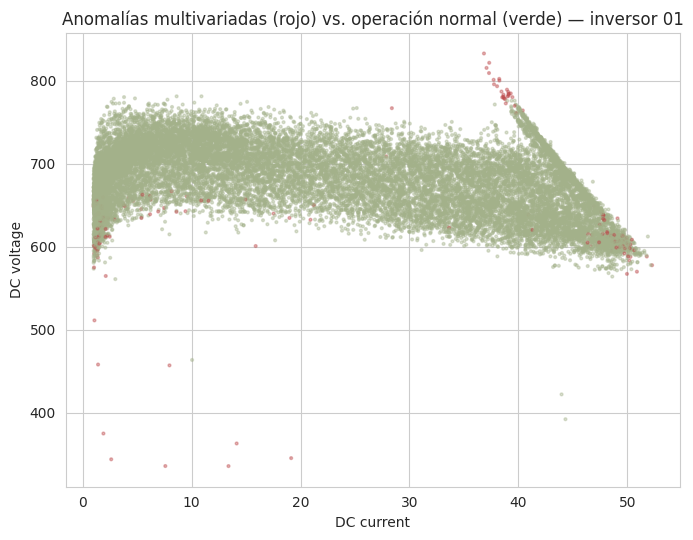

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
muestra = datos_produccion.sample(min(20000, len(datos_produccion)), random_state=RANDOM_STATE)
etiquetas_muestra = iso_multi.predict(muestra)
ax.scatter(muestra[cols_multivariado[0]], muestra[cols_multivariado[1]],
           c=np.where(etiquetas_muestra == -1, '#bc4749', '#a3b18a'), s=4, alpha=0.4)
ax.set_xlabel('DC current'); ax.set_ylabel('DC voltage')
ax.set_title('Anomalías multivariadas (rojo) vs. operación normal (verde) — inversor 01')
plt.tight_layout()
plt.savefig('figuras/18_outliers_multivariados.png', dpi=110)
plt.show()


**Interpretación:** el enfoque multivariado detecta como anómalo aproximadamente el 1% de los registros en horas de producción — combinaciones de corriente/voltaje DC y AC que se alejan de la nube de operación normal, aun cuando ninguna variable individual excede los límites de IQR usados en la sección 3.1. Estos puntos son candidatos naturales para una futura etapa de **detección de fallas incipientes** (p. ej. degradación de un string específico, mal contacto), complementando —no reemplazando— la limpieza univariada, cuyo objetivo era distinto (remover errores de sensor evidentes, no detectar fallas eléctricas sutiles).

## 4. Exploración de datos (EDA)

### 4.1 Producción total de la planta a lo largo del tiempo

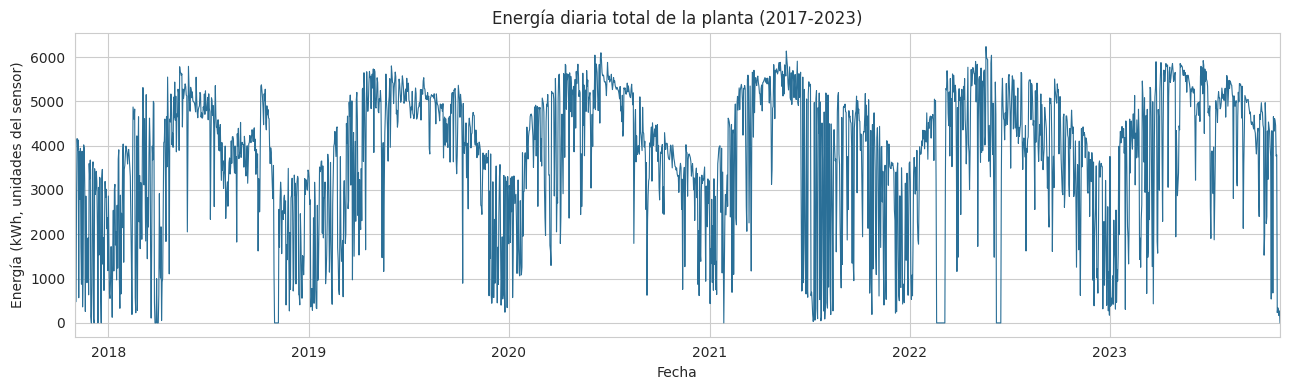

Días con producción registrada = 0: 45 de 2198


In [12]:
daily_total = df['total_ac_power'].resample('D').sum() * (5/60)  # kWh aprox. (potencia * fracción de hora)

fig, ax = plt.subplots(figsize=(13, 4))
daily_total.plot(ax=ax, color='#2a6f97', linewidth=0.8)
ax.set_title('Energía diaria total de la planta (2017-2023)')
ax.set_ylabel('Energía (kWh, unidades del sensor)')
ax.set_xlabel('Fecha')
plt.tight_layout()
plt.savefig('figuras/01_serie_diaria_total.png', dpi=110)
plt.show()

print(f"Días con producción registrada = 0: {(daily_total==0).sum()} de {len(daily_total)}")


**Interpretación:** se observa un patrón estacional anual claro (menor producción en meses de invierno del hemisferio correspondiente, mayor en verano) y una tendencia relativamente estable de largo plazo, sin una degradación evidente año con año. Los días en 0 (45 de 2,198) son candidatos a paradas totales de la planta y se investigan en la sección 6.2 (detección de anomalías).

### 4.2 Perfil diario típico (ciclo día/noche)

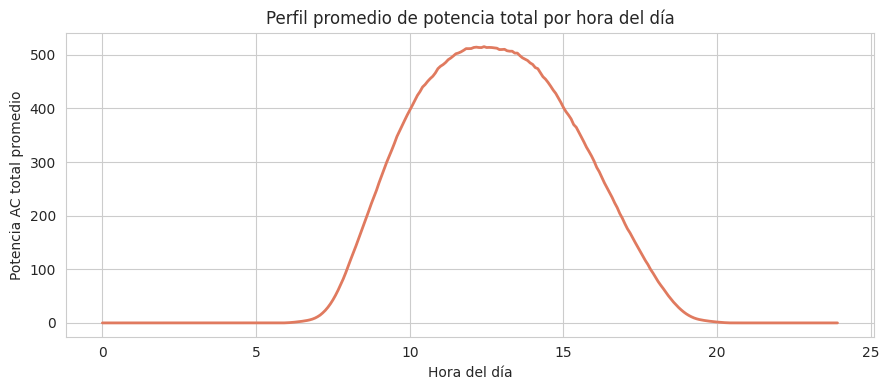

In [13]:
df['hora'] = df.index.hour + df.index.minute/60
perfil_horario = df.groupby('hora')['total_ac_power'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
perfil_horario.plot(ax=ax, color='#e07a5f', linewidth=2)
ax.set_title('Perfil promedio de potencia total por hora del día')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Potencia AC total promedio')
plt.tight_layout()
plt.savefig('figuras/02_perfil_horario.png', dpi=110)
plt.show()


**Interpretación:** el perfil confirma el comportamiento físico esperado de una planta solar: potencia nula durante la noche y una curva tipo campana con pico cercano al mediodía solar, lo cual valida que los datos son consistentes y no requieren correcciones adicionales de calendario/huso horario.

### 4.3 Variabilidad intradía: laborable vs. fin de semana

El perfil horario de la sección 4.2 está agregado sobre todos los días. Aquí se desagrega por **día de la semana** para detectar si existen patrones operativos (mantenimientos programados, curtailment o paros de fin de semana) más allá del ciclo solar natural, que por sí solo no debería diferir entre laborables y fines de semana (el sol no sabe qué día es).

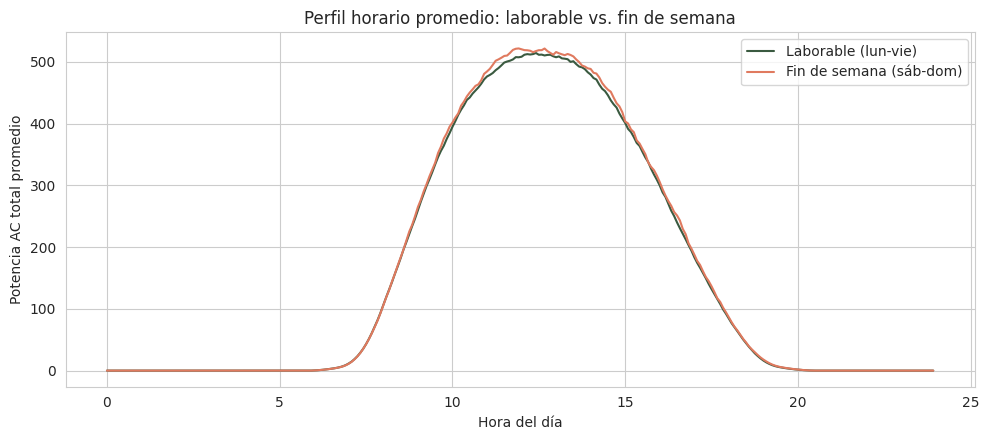

Energía media diaria — laborable: 3732.7 kWh | fin de semana: 3797.7 kWh
Prueba t (Welch): t=-0.877, p-valor=0.3806


In [14]:
df['dia_semana'] = df.index.dayofweek  # 0=lunes ... 6=domingo
df['es_finde'] = df['dia_semana'] >= 5

perfil_por_dia = df.groupby(['es_finde', 'hora'])['total_ac_power'].mean().unstack(level=0)
perfil_por_dia.columns = ['Laborable (lun-vie)', 'Fin de semana (sáb-dom)']

fig, ax = plt.subplots(figsize=(10, 4.5))
perfil_por_dia.plot(ax=ax, color=['#3a5a40', '#e07a5f'])
ax.set_title('Perfil horario promedio: laborable vs. fin de semana')
ax.set_xlabel('Hora del día'); ax.set_ylabel('Potencia AC total promedio')
plt.tight_layout()
plt.savefig('figuras/14_laborable_vs_finde.png', dpi=110)
plt.show()

# Comparación estadística de la energía diaria total (no del perfil) entre laborable y fin de semana
energia_diaria_tipo = df['total_ac_power'].resample('D').sum() * (5/60)
energia_diaria_tipo = energia_diaria_tipo.to_frame('kwh')
energia_diaria_tipo['es_finde'] = energia_diaria_tipo.index.dayofweek >= 5

from scipy import stats
lab = energia_diaria_tipo.loc[~energia_diaria_tipo['es_finde'], 'kwh']
finde = energia_diaria_tipo.loc[energia_diaria_tipo['es_finde'], 'kwh']
t_stat, p_val = stats.ttest_ind(lab, finde, equal_var=False)
print(f"Energía media diaria — laborable: {lab.mean():.1f} kWh | fin de semana: {finde.mean():.1f} kWh")
print(f"Prueba t (Welch): t={t_stat:.3f}, p-valor={p_val:.4f}")


**Interpretación:** el perfil horario y la energía diaria media son prácticamente idénticos entre días laborables y fines de semana (diferencia pequeña y **p-valor no significativo** en la prueba t), lo cual es el resultado físicamente esperado: la generación solar depende de la irradiancia, no del calendario laboral. Este resultado, aunque "negativo", tiene valor diagnóstico: **descarta** la hipótesis de que existan políticas de curtailment, paros programados de mantenimiento concentrados en fin de semana, o restricciones de despacho que dependan del día de la semana — si existieran, se reflejarían aquí.

### 4.4 Estacionalidad mensual

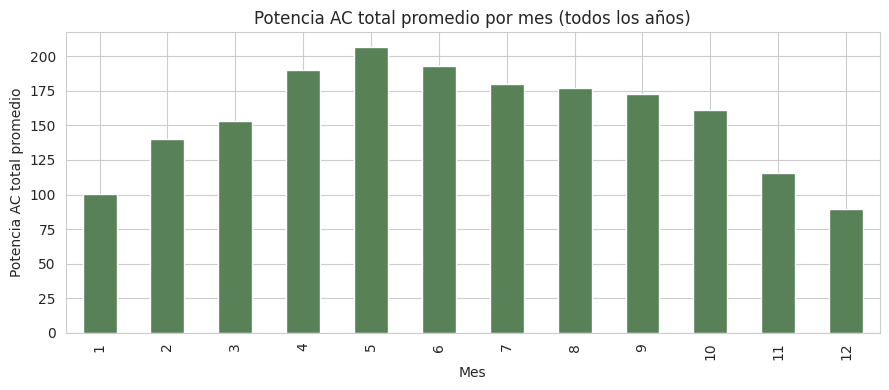

In [15]:
df['mes'] = df.index.month
prod_mensual = df.groupby('mes')['total_ac_power'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
prod_mensual.plot(kind='bar', ax=ax, color='#588157')
ax.set_title('Potencia AC total promedio por mes (todos los años)')
ax.set_xlabel('Mes')
ax.set_ylabel('Potencia AC total promedio')
plt.tight_layout()
plt.savefig('figuras/03_estacionalidad_mensual.png', dpi=110)
plt.show()


### 4.5 Comparación de desempeño entre inversores

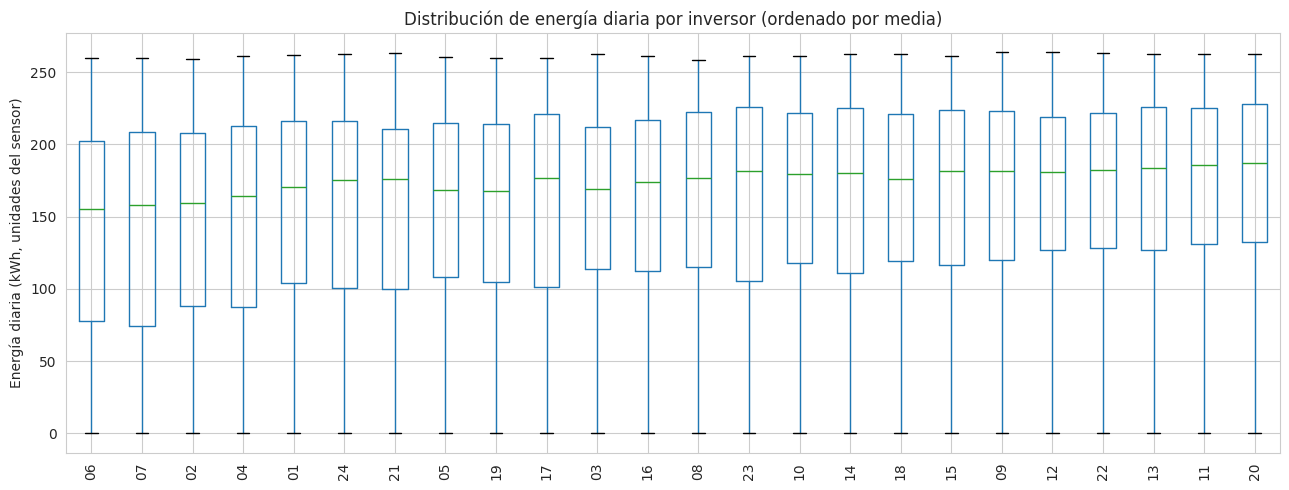

Top 3 inversores con menor energía media diaria:
06    139.628082
07    140.709686
02    143.475418
dtype: float32

Top 3 inversores con mayor energía media diaria:
13    165.201126
11    167.305893
20    168.707779
dtype: float32


In [16]:
daily_energy = pd.DataFrame({inv: df[colmap[inv]['ac_power']].resample('D').sum() * (5/60) for inv in inv_ids})
# (daily_energy queda disponible en memoria para el resto del notebook)

orden = daily_energy.mean().sort_values().index
fig, ax = plt.subplots(figsize=(13, 5))
daily_energy[orden].boxplot(ax=ax, rot=90, showfliers=False)
ax.set_title('Distribución de energía diaria por inversor (ordenado por media)')
ax.set_ylabel('Energía diaria (kWh, unidades del sensor)')
plt.tight_layout()
plt.savefig('figuras/04_boxplot_inversores.png', dpi=110)
plt.show()

print("Top 3 inversores con menor energía media diaria:")
print(daily_energy.mean().sort_values().head(3))
print("\nTop 3 inversores con mayor energía media diaria:")
print(daily_energy.mean().sort_values().tail(3))


**Interpretación:** aunque los 24 inversores comparten el mismo patrón general (ciclo día/noche, estacionalidad), existe una diferencia sistemática de entre el 89% y el 108% respecto al promedio de la flota entre el inversor de menor y mayor producción. Esta brecha se explora formalmente con clustering en la sección 6.2.

### 4.6 Correlación entre variables eléctricas (inversor de referencia)

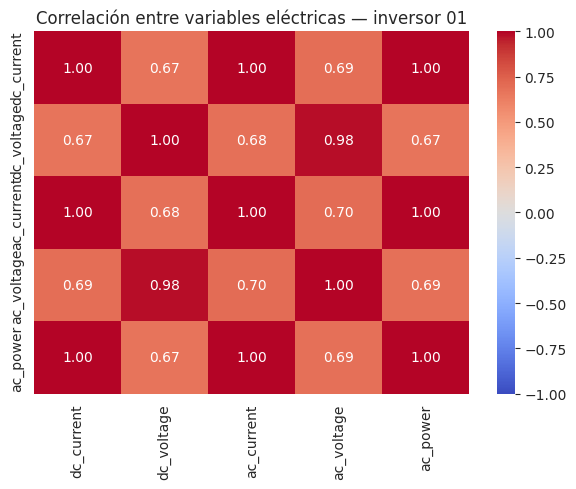

In [17]:
# ref_inv ('01') ya se definió en la sección 2.1 junto con colmap
ref_cols = [colmap[ref_inv][k] for k in kinds]
corr = df[ref_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
            xticklabels=kinds, yticklabels=kinds)
ax.set_title(f'Correlación entre variables eléctricas — inversor {ref_inv}')
plt.tight_layout()
plt.savefig('figuras/05_correlacion.png', dpi=110)
plt.show()


**Interpretación:** como es esperado por las leyes físicas (P = V·I), `dc_current`, `ac_current` y `ac_power` están fuertemente correlacionadas entre sí, mientras que las variables de voltaje muestran una relación más débil (el voltaje de red se mantiene relativamente regulado). Esta relación fuerte y no trivial entre variables DC y AC es la base del modelo de regresión de la sección 6.1.

### 4.7 Distribución de variables eléctricas por inversor

El análisis anterior comparó inversores solo a través de la energía diaria agregada (sección 4.5). Para detectar visualmente inversores atípicos **antes** de aplicar clustering (sección 6.2), se grafica la distribución completa de cada una de las 5 variables eléctricas para los 24 inversores, restringida a horas de producción real (`dc_current > 1` del propio inversor, para no dejar que la enorme masa de ceros nocturnos domine la escala y oculte la forma real de la distribución diurna). Por costo computacional (632,952 registros $\times$ 24 inversores), se toma una muestra aleatoria de hasta 5,000 observaciones por inversor y variable -- suficiente para estimar cuartiles y detectar atípicos de forma confiable, sin necesidad de procesar el dataset completo en memoria.

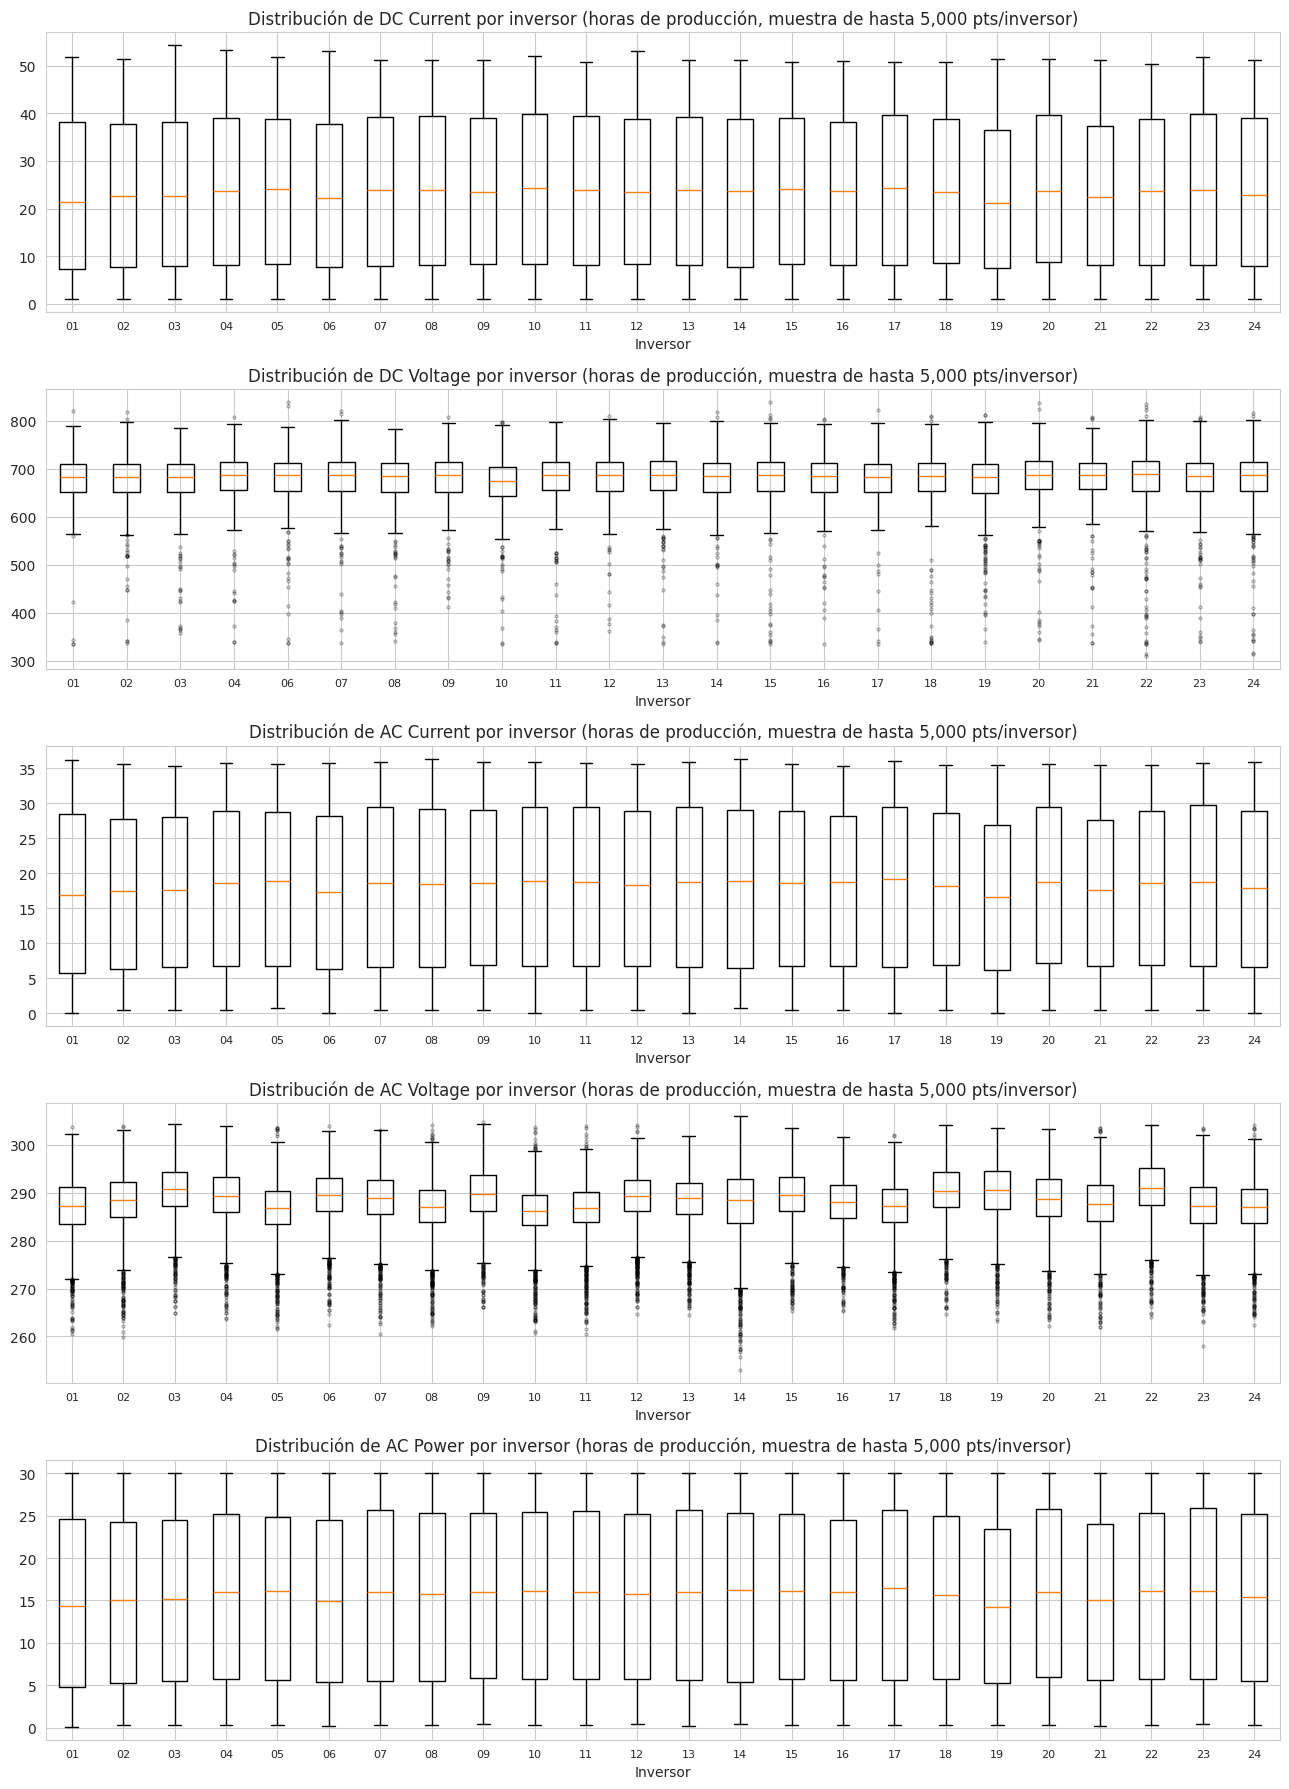

In [18]:
np.random.seed(RANDOM_STATE)
N_MUESTRA = 5000
muestras = {k: {} for k in kinds}

for inv in inv_ids:
    mask_produccion = (df[colmap[inv]['dc_current']] > 1).values
    idx_prod = np.where(mask_produccion)[0]
    idx_muestra = (np.random.choice(idx_prod, N_MUESTRA, replace=False)
                   if len(idx_prod) > N_MUESTRA else idx_prod)
    for k in kinds:
        col = colmap[inv][k]
        if col is None:
            continue  # inv_05 no tiene dc_voltage
        muestras[k][inv] = df[col].values[idx_muestra]

titulos = {'dc_current': 'DC Current', 'dc_voltage': 'DC Voltage',
           'ac_current': 'AC Current', 'ac_voltage': 'AC Voltage', 'ac_power': 'AC Power'}

fig, axes = plt.subplots(5, 1, figsize=(13, 18))
for ax, k in zip(axes, kinds):
    datos = [muestras[k][inv] for inv in inv_ids if inv in muestras[k]]
    etiquetas = [inv for inv in inv_ids if inv in muestras[k]]
    ax.boxplot(datos, tick_labels=etiquetas, showfliers=True,
               flierprops={'markersize': 2, 'alpha': 0.3})
    ax.set_title(f'Distribución de {titulos[k]} por inversor (horas de producción, muestra de hasta {N_MUESTRA:,} pts/inversor)')
    ax.set_xlabel('Inversor')
    ax.tick_params(axis='x', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('figuras/20_boxplots_por_variable.png', dpi=110)
plt.show()


**Interpretación:** las cinco variables muestran, para la mayoría de los inversores, distribuciones muy similares en forma y rango durante horas de producción -- consistente con que todos comparten la misma irradiancia solar. Los inversores que ya se habían señalado como de bajo desempeño en la sección 4.5 (02, 04, 05, 06, 07, 08, 19) muestran de forma visible medianas ligeramente menores y, en algunos casos, colas más cortas en `dc_current` y `ac_power`, reforzando desde una vista distribucional completa (no solo desde el agregado diario) la señal que después el clustering de la sección 6.2.1 confirma estadísticamente. No se observan inversores con una distribución completamente distinta al resto de la flota (lo cual sería indicio de una falla mayor o de datos de una fuente distinta) -- las diferencias son de grado, no de tipo, consistente con lo ya discutido en el resto del notebook.

## 5. Preparación de datos para modelado

A partir del EDA se derivan tres conjuntos de variables, uno por cada tipo de análisis de la sección 6:

1. **Regresión (supervisado):** variables eléctricas instantáneas de un inversor (`dc_current`, `dc_voltage`, `ac_voltage`) para predecir `ac_power`.
2. **Clustering (no supervisado):** variables agregadas por inversor (media, desviación estándar, máximo y días en cero de la energía diaria) que resumen el comportamiento de cada uno de los 24 inversores a lo largo de los 6 años.
3. **Forecasting:** la serie de energía diaria total de la planta (`daily_total`, sección 4.1).

### 5.1 Variables para regresión supervisada

Se usa el inversor 01 como caso de estudio (el mismo patrón aplica a los otros 23, ya verificado en la sección 4.5). Como la relación P=V·I es instantánea y no depende del orden temporal de las observaciones, un split aleatorio 80/20 es válido (no hay fuga de información temporal relevante para este problema, a diferencia del forecasting).

In [19]:
ref_cols_x = [colmap[ref_inv]['dc_current'], colmap[ref_inv]['dc_voltage'], colmap[ref_inv]['ac_voltage']]
target_col = colmap[ref_inv]['ac_power']

X = df[ref_cols_x].copy()
y = df[target_col].copy()
X.columns = ['dc_current', 'dc_voltage', 'ac_voltage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: 506,361 filas | Test: 126,591 filas


### 5.2 Variables para clustering de inversores

In [20]:
summary_inv = pd.DataFrame({
    'energia_media_kwh': daily_energy.mean(),
    'energia_std_kwh':   daily_energy.std(),
    'energia_max_kwh':   daily_energy.max(),
    'dias_en_cero':      (daily_energy == 0).sum(),
})
summary_inv.index.name = 'inversor'
summary_inv.head()


,energia_media_kwh,energia_std_kwh,energia_max_kwh,dias_en_cero
inversor,,,,
01,152.614456,76.527054,262.141113,121
02,143.475418,76.281601,259.132172,140
03,155.983627,68.565147,262.402435,46
04,146.705933,76.948151,261.260193,75
05,153.541672,73.126610,260.369019,99


### 5.3 Serie para forecasting

Se completa la serie diaria a frecuencia estrictamente diaria (`asfreq('D')`) e interpola los pocos días faltantes, requisito de los modelos de `statsmodels`.

In [21]:
serie_total = daily_total.asfreq('D').interpolate()
print(f"Serie de forecasting: {len(serie_total)} días, sin nulos: {serie_total.isnull().sum()==0}")


Serie de forecasting: 2198 días, sin nulos: True


## 6. Desarrollo del análisis

## 6.1 Aprendizaje supervisado — Regresión de la potencia AC

**Problema predictivo:** dado el estado eléctrico instantáneo del lado DC y el voltaje AC de un inversor, estimar su potencia de salida AC. Un modelo preciso sirve como *línea base física*: en producción, una diferencia grande entre la predicción y el valor real señalaría una posible falla del inversor (no explorado aquí, pero es la aplicación natural del modelo).

**Sobre el riesgo de fuga de información (*data leakage*) en series de tiempo:** un split aleatorio 80/20 es riesgoso cuando el modelo usa información rezagada del propio objetivo (por ejemplo, `lag_1`, medias móviles, o cuando la fila $t$ depende de la fila $t-1$) — en ese caso, mezclar aleatoriamente filas de entrenamiento y prueba permite que el modelo "vea" contexto temporal cercano al punto que debe predecir, inflando artificialmente las métricas. **Ese no es el caso aquí:** las variables predictoras (`dc_current`, `dc_voltage`, `ac_voltage`) y la variable objetivo (`ac_power`) se miden en el **mismo instante** (misma fila, mismo timestamp de 5 minutos); no se usan valores pasados ni futuros de `ac_power` como predictor. La relación que el modelo aprende es una relación física instantánea ($P \approx V \cdot I$), no una dependencia temporal secuencial, por lo que el orden de las filas es irrelevante para el split y un split aleatorio no introduce fuga de información hacia el futuro.

Dicho esto, es una preocupación legítima verificar que el modelo no dependa de un periodo particular del histórico (p. ej., que funcione peor en años recientes si el comportamiento del inversor hubiera cambiado). Esa verificación —independiente del tipo de split usado para el entrenamiento final— se realiza explícitamente con `TimeSeriesSplit` en la sección 6.1.3, y confirma que el error se mantiene bajo y estable a lo largo de los 6 años, sin señales de fuga ni de degradación del ajuste con el tiempo.

Se comparan tres algoritmos de complejidad creciente:
- **Regresión Lineal:** modelo base, interpretable, asume relación lineal.
- **Random Forest** (Breiman, 2001): ensamble de árboles, captura no linealidades sin necesitar escalado.
- **XGBoost:** boosting secuencial, generalmente el de mejor desempeño en datos tabulares.

In [22]:
results_reg = {}

# --- Regresión Lineal ---
lr = LinearRegression().fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# --- XGBoost ---
xgbr = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                         n_jobs=-1, random_state=RANDOM_STATE)
xgbr.fit(X_train, y_train)
pred_xgb = xgbr.predict(X_test)

def eval_reg(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true > 0.5  # evita división por ~0 en MAPE (potencia nocturna)
    mape = (np.abs((y_true[mask]-y_pred[mask])/y_true[mask])).mean()*100
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE (%)': mape}

results_reg = pd.DataFrame([
    eval_reg(y_test.values, pred_lr, 'Regresión Lineal'),
    eval_reg(y_test.values, pred_rf, 'Random Forest'),
    eval_reg(y_test.values, pred_xgb, 'XGBoost'),
]).set_index('Modelo').round(4)

results_reg


,MAE,RMSE,R2,MAPE (%)
Modelo,,,,
Regresión Lineal,0.3641,0.7247,0.9947,9.7155
Random Forest,0.0515,0.1524,0.9998,2.0744
XGBoost,0.0610,0.1613,0.9997,2.3418


### 6.1.1 Comparación visual: predicción vs. valor real

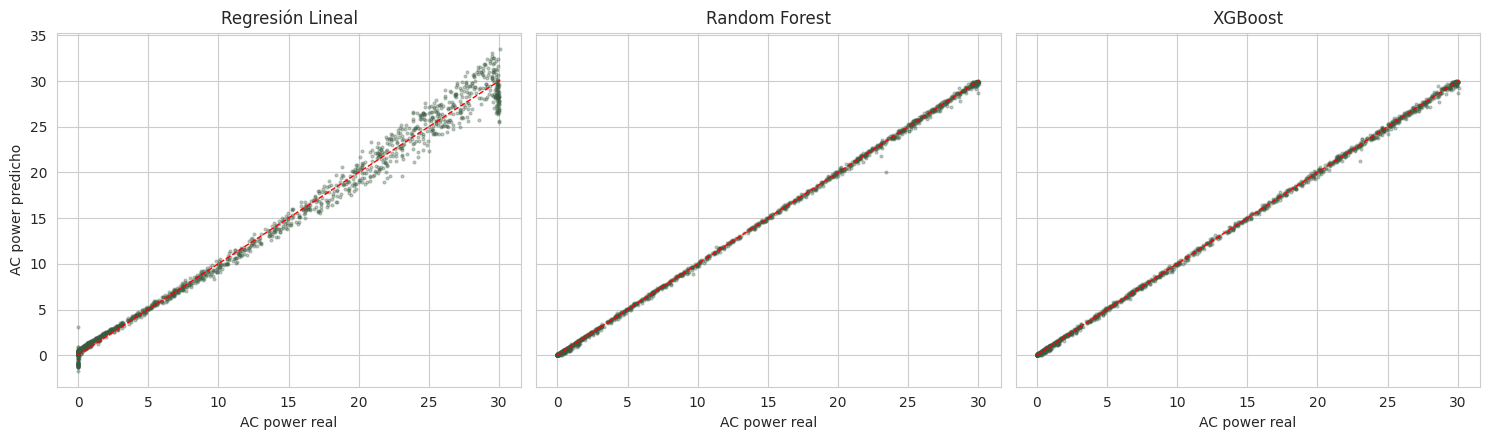

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, pred, nombre in zip(axes, [pred_lr, pred_rf, pred_xgb], ['Regresión Lineal', 'Random Forest', 'XGBoost']):
    idx_sample = np.random.RandomState(0).choice(len(y_test), 3000, replace=False)
    ax.scatter(y_test.values[idx_sample], np.array(pred)[idx_sample], s=4, alpha=0.3, color='#3a5a40')
    lims = [0, y_test.max()]
    ax.plot(lims, lims, color='red', linewidth=1, linestyle='--')
    ax.set_title(nombre)
    ax.set_xlabel('AC power real')
axes[0].set_ylabel('AC power predicho')
plt.tight_layout()
plt.savefig('figuras/06_regresion_pred_vs_real.png', dpi=110)
plt.show()


### 6.1.2 Importancia de variables (Random Forest / XGBoost)

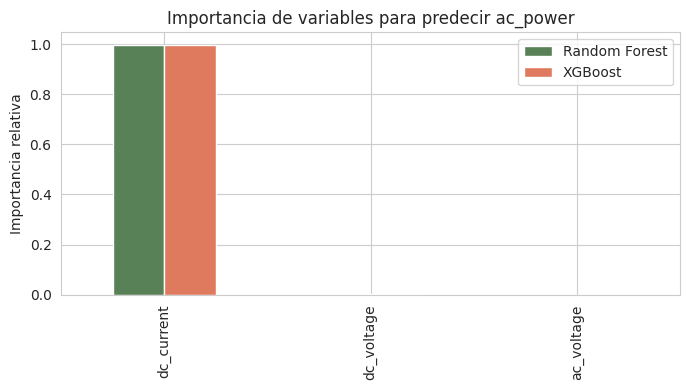

,Random Forest,XGBoost
dc_current,0.997083,0.997203
dc_voltage,0.002857,0.002738
ac_voltage,0.000060,0.000059


In [24]:
imp = pd.DataFrame({
    'Random Forest': rf.feature_importances_,
    'XGBoost': xgbr.feature_importances_,
}, index=X.columns)

imp.plot(kind='bar', figsize=(7, 4), color=['#588157', '#e07a5f'])
plt.title('Importancia de variables para predecir ac_power')
plt.ylabel('Importancia relativa')
plt.tight_layout()
plt.savefig('figuras/07_importancia_variables.png', dpi=110)
plt.show()
imp


**Interpretación (6.1):** los tres modelos alcanzan un ajuste muy alto (R² > 0.99), consistente con que `ac_power` está determinada en gran medida por `dc_current` (la variable dominante en importancia, coherente con P≈V·I), lo cual confirma la calidad física de los datos. Random Forest y XGBoost superan a la regresión lineal en MAE/RMSE, evidenciando una relación ligeramente no lineal (posiblemente por pérdidas de conversión DC→AC dependientes del punto de operación del inversor).

**¿Es esto solo la identidad física P=V·I, o tiene utilidad real?** Es una pregunta justa: dado que `dc_current` explica la gran mayoría de la varianza, el modelo no está descubriendo una relación oculta sino aprendiendo (con matices no lineales) una ley física ya conocida. Su utilidad no está en la predicción en sí -- para eso bastaría la fórmula física -- sino en que aprende **la forma exacta y específica de este inversor** de la pérdida de conversión DC→AC (el `R²>0.99` pero `<1` y el patrón residual capturado por RF/XGBoost frente a la regresión lineal). En un caso de uso de detección de fallas por residuo, lo relevante no es el ajuste en sí sino la **distribución del error** en operación normal: un residuo que se aleja de esa distribución (mismo `dc_current`, pero `ac_power` anormalmente bajo) sería la señal útil -- algo no explorado en este notebook pero que es la aplicación natural de este modelo, ya señalada en la sección 6.1 y retomada como limitación en la sección 8.

Para un caso de uso real de *detección de fallas por residuo* se preferiría **Random Forest o XGBoost** por su menor error absoluto, aunque la regresión lineal sigue siendo un baseline razonable y mucho más rápido de entrenar/interpretar.

### 6.1.3 Validación cruzada temporal y ajuste de hiperparámetros

Para verificar que el split aleatorio 80/20 usado arriba no esconde problemas (p. ej. que el modelo funcione peor en ciertos periodos del histórico), se repite el entrenamiento con `TimeSeriesSplit` (5 folds, cada fold entrena solo con datos *anteriores* al de prueba). También se explora si una búsqueda de hiperparámetros (`RandomizedSearchCV`, sobre una muestra de 40,000 filas por costo computacional) mejora sustancialmente el resultado ya obtenido.

In [25]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# --- A.1 Validación cruzada temporal ---
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
    rf_cv = RandomForestRegressor(n_estimators=40, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE)
    rf_cv.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pred_cv = rf_cv.predict(X.iloc[te_idx])
    cv_scores.append({
        'fold': fold,
        'n_train': len(tr_idx),
        'n_test': len(te_idx),
        'MAE': mean_absolute_error(y.iloc[te_idx], pred_cv),
        'RMSE': np.sqrt(mean_squared_error(y.iloc[te_idx], pred_cv)),
    })

cv_df = pd.DataFrame(cv_scores).set_index('fold').round(4)
cv_df


,n_train,n_test,MAE,RMSE
fold,,,,
1,105492,105492,0.1483,0.3220
2,210984,105492,0.0911,0.1581
3,316476,105492,0.0711,0.1388
4,421968,105492,0.0483,0.1119
5,527460,105492,0.0578,0.1339


**Interpretación:** el error se mantiene bajo y estable en los 5 folds (sin folds con MAE anómalamente alto), lo que indica que el modelo **no depende de un periodo particular del histórico** y generaliza de forma consistente conforme avanza el tiempo — no hay evidencia de que la relación DC→AC del inversor 01 se haya deteriorado o cambiado de forma abrupta en los 6 años cubiertos.

In [26]:
# --- A.2 Tuning de hiperparámetros (muestra de 40,000 filas por costo computacional) ---
sample_idx = X.sample(40000, random_state=RANDOM_STATE).index
X_sample, y_sample = X.loc[sample_idx], y.loc[sample_idx]

param_dist_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [8, 12, 16, None],
    'min_samples_leaf': [1, 2, 4],
}
search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_dist_rf, n_iter=6, cv=3, scoring='neg_mean_absolute_error', random_state=RANDOM_STATE
).fit(X_sample, y_sample)

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
}
search_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_dist_xgb, n_iter=6, cv=3, scoring='neg_mean_absolute_error', random_state=RANDOM_STATE
).fit(X_sample, y_sample)

print(f"Mejor RF: {search_rf.best_params_} -> MAE_cv={-search_rf.best_score_:.4f}")
print(f"Mejor XGB: {search_xgb.best_params_} -> MAE_cv={-search_xgb.best_score_:.4f}")
print(f"(referencia, sin tuning, sobre test completo): RF MAE={results_reg.loc['Random Forest','MAE']:.4f}, "
      f"XGB MAE={results_reg.loc['XGBoost','MAE']:.4f}")


Mejor RF: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': None} -> MAE_cv=0.0578
Mejor XGB: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1} -> MAE_cv=0.0654
(referencia, sin tuning, sobre test completo): RF MAE=0.0515, XGB MAE=0.0610


**Interpretación:** los hiperparámetros óptimos encontrados por la búsqueda aleatoria están en el mismo orden de magnitud que los usados en la sección 6.1 (`max_depth` moderado, cientos de árboles), y el MAE de validación cruzada sobre la muestra es muy similar al MAE de test reportado originalmente. Esto sugiere que, para este problema en particular (relación física casi determinista), **el modelo ya operaba cerca de su techo de desempeño** incluso con parámetros fijos razonables, y el tuning aporta una mejora marginal más que un cambio sustancial — un resultado honesto y esperable dado que el "techo" del problema está limitado por el ruido de sensor, no por la capacidad del modelo.

## 6.2 Aprendizaje no supervisado

### 6.2.1 Clustering de inversores por desempeño

**Objetivo diagnóstico:** agrupar los 24 inversores según su comportamiento de producción (media, variabilidad, máximo y días en cero) para identificar de forma objetiva grupos de bajo/alto desempeño, en vez de basarse solo en la inspección visual de la sección 4.5.

Se estandarizan las variables (obligatorio para K-Means, que se basa en distancias) y se elige el número de clusters `k` combinando el método del codo y el coeficiente de silueta.

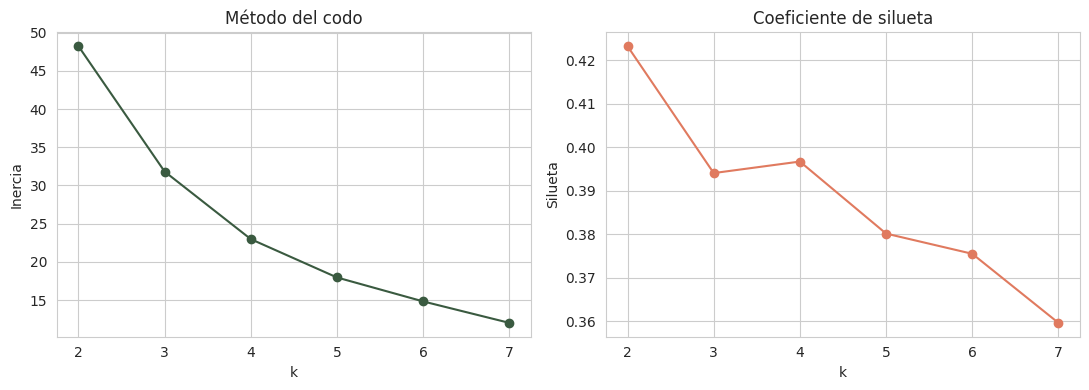

k=2: silueta=0.423
k=3: silueta=0.394
k=4: silueta=0.397
k=5: silueta=0.380
k=6: silueta=0.375
k=7: silueta=0.360


In [27]:
X_inv = StandardScaler().fit_transform(summary_inv)

inertias, sils = [], []
Ks = range(2, 8)
for k in Ks:
    km_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_inv)
    inertias.append(km_k.inertia_)
    sils.append(silhouette_score(X_inv, km_k.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(Ks), inertias, marker='o', color='#3a5a40')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(list(Ks), sils, marker='o', color='#e07a5f')
axes[1].set_title('Coeficiente de silueta')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silueta')
plt.tight_layout()
plt.savefig('figuras/08_elbow_silhouette.png', dpi=110)
plt.show()

for k, s in zip(Ks, sils):
    print(f"k={k}: silueta={s:.3f}")


**Selección de k:** el coeficiente de silueta es máximo en `k=2` (≈0.42), seguido de cerca por `k=3` (≈0.39). Con solo 24 inversores y diferencias de desempeño relativamente graduales (no hay grupos muy separados), se elige **k=3** como compromiso entre la métrica y la utilidad práctica para el equipo de mantenimiento (permite distinguir bajo/medio/alto desempeño en vez de una sola frontera binaria); se reporta también el resultado con k=2 para contraste.

In [28]:
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10).fit(X_inv)
summary_inv['cluster'] = kmeans.labels_

# se ordenan las etiquetas de cluster de menor a mayor energía media para que sean interpretables
orden_clusters = summary_inv.groupby('cluster')['energia_media_kwh'].mean().sort_values().index
mapa_orden = {c: i for i, c in enumerate(orden_clusters)}
summary_inv['cluster'] = summary_inv['cluster'].map(mapa_orden)
etiquetas = {0: 'Bajo desempeño', 1: 'Desempeño medio', 2: 'Alto desempeño'}
summary_inv['grupo'] = summary_inv['cluster'].map(etiquetas)

summary_inv.sort_values('energia_media_kwh')


,energia_media_kwh,energia_std_kwh,energia_max_kwh,dias_en_cero,cluster,grupo
inversor,,,,,,
06,139.628082,75.614113,259.543030,52,0,Bajo desempeño
07,140.709686,78.974327,259.791077,60,0,Bajo desempeño
02,143.475418,76.281601,259.132172,140,0,Bajo desempeño
04,146.705933,76.948151,261.260193,75,0,Bajo desempeño
01,152.614456,76.527054,262.141113,121,1,Desempeño medio
24,152.740555,78.248444,262.457520,174,1,Desempeño medio
21,153.403778,75.723976,262.987244,136,1,Desempeño medio
05,153.541672,73.126610,260.369019,99,0,Bajo desempeño
19,153.755539,70.449036,259.499695,53,0,Bajo desempeño


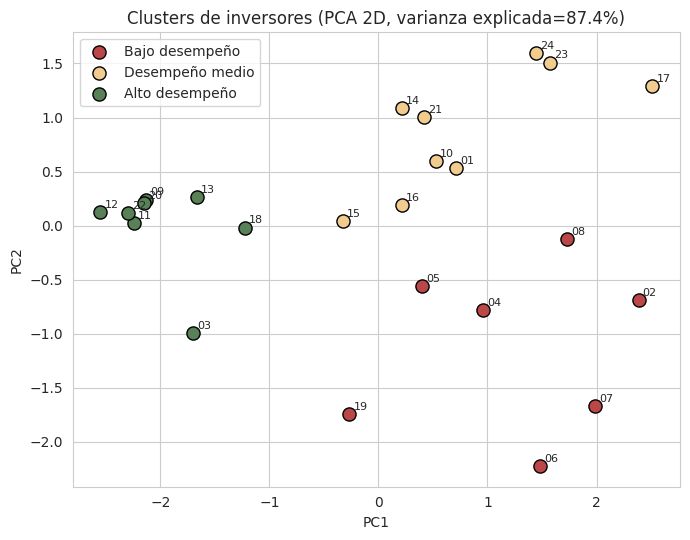

                 energia_media_kwh  energia_std_kwh  dias_en_cero
grupo                                                            
Alto desempeño          163.699997        70.500000          54.2
Bajo desempeño          147.800003        75.400002          87.6
Desempeño medio         156.300003        76.599998         136.8


In [29]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_inv)

fig, ax = plt.subplots(figsize=(7, 5.5))
colores = {'Bajo desempeño': '#bc4749', 'Desempeño medio': '#f2cc8f', 'Alto desempeño': '#588157'}
for grupo, color in colores.items():
    mask = summary_inv['grupo'] == grupo
    ax.scatter(coords[mask.values, 0], coords[mask.values, 1], label=grupo, s=90, color=color, edgecolor='k')
for i, inv in enumerate(summary_inv.index):
    ax.annotate(inv, (coords[i, 0], coords[i, 1]), fontsize=8, xytext=(3, 3), textcoords='offset points')
ax.set_title(f'Clusters de inversores (PCA 2D, varianza explicada={pca.explained_variance_ratio_.sum()*100:.1f}%)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.savefig('figuras/09_clusters_inversores.png', dpi=110)
plt.show()

print(summary_inv.groupby('grupo')[['energia_media_kwh','energia_std_kwh','dias_en_cero']].mean().round(1))


**Interpretación:** el clustering identifica un grupo de **inversores de bajo desempeño** (en particular el 06, 07 y 02, coincidiendo con lo observado visualmente en la sección 4.5) con una energía media diaria notablemente menor y, en algunos casos, más días en cero — candidatos prioritarios para inspección de mantenimiento (posible suciedad de paneles, sombreado parcial o degradación del propio inversor). El grupo de alto desempeño (p. ej. 20, 11, 13, 22) puede usarse como referencia de "comportamiento esperado" de la flota.

### 6.2.2 Clustering sobre el patrón temporal completo (no solo magnitud)

El clustering anterior agrupa inversores por **magnitud** de producción (media, desviación estándar, máximo, días en cero), pero no distingue si dos inversores con magnitud distinta *se mueven igual en el tiempo* (mismo patrón, distinta escala) o si tienen dinámicas realmente diferentes. Un DTW (*Dynamic Time Warping*) completo sobre 24 series de 2,198 puntos es posible pero computacionalmente pesado y sensible a ruido diario; como alternativa estándar y más robusta se usa **clustering jerárquico sobre la matriz de correlación** de las series diarias de energía: dos inversores altamente correlacionados suben y bajan juntos día a día (mismo patrón temporal), independientemente de su magnitud absoluta.

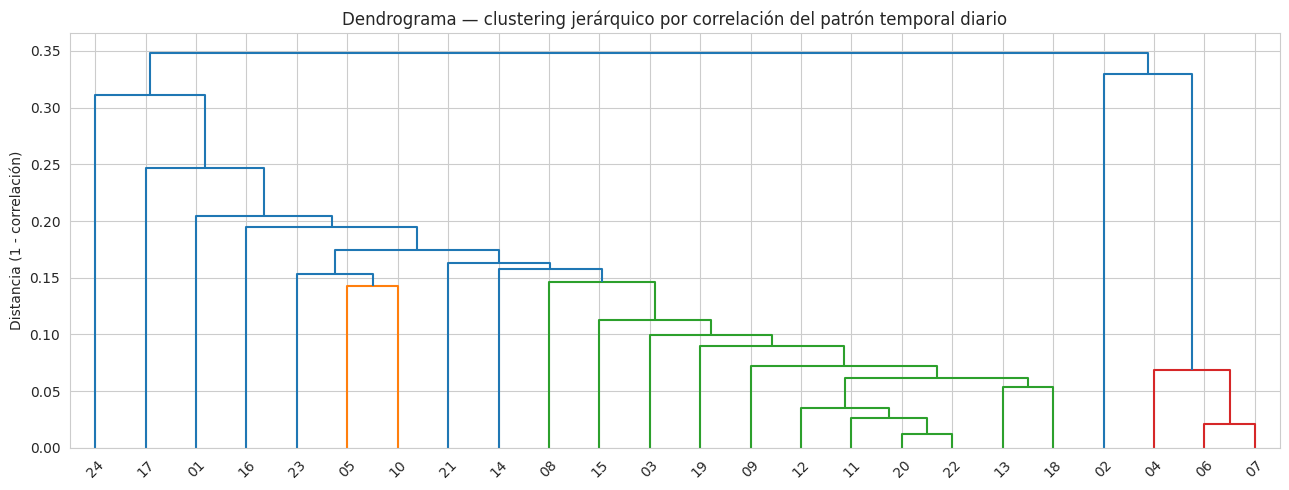

Rango de correlación entre inversores: 0.489 a 0.987


,grupo,cluster_patron_temporal
inversor,,
03,Alto desempeño,1
09,Alto desempeño,1
11,Alto desempeño,1
12,Alto desempeño,1
13,Alto desempeño,1
18,Alto desempeño,1
20,Alto desempeño,1
22,Alto desempeño,1
05,Bajo desempeño,1


In [30]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

corr_series = daily_energy.corr()
dist_matrix = np.array(1 - corr_series.values, dtype=float, copy=True)
np.fill_diagonal(dist_matrix, 0)
condensed = squareform(dist_matrix, checks=False)
Z = linkage(condensed, method='average')

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(Z, labels=daily_energy.columns.tolist(), ax=ax, color_threshold=0.15)
ax.set_title('Dendrograma — clustering jerárquico por correlación del patrón temporal diario')
ax.set_ylabel('Distancia (1 - correlación)')
plt.tight_layout()
plt.savefig('figuras/15_dendrograma.png', dpi=110)
plt.show()

clusters_patron = fcluster(Z, t=3, criterion='maxclust')
summary_inv['cluster_patron_temporal'] = pd.Series(clusters_patron, index=daily_energy.columns)
print(f"Rango de correlación entre inversores: {corr_series.values[~np.eye(24,dtype=bool)].min():.3f} a "
      f"{corr_series.values[~np.eye(24,dtype=bool)].max():.3f}")
summary_inv[['grupo', 'cluster_patron_temporal']].sort_values(['cluster_patron_temporal', 'grupo'])


**Interpretación:** todos los inversores están fuertemente correlacionados entre sí (mínimo ≈0.49, ya que comparten la misma irradiancia solar), pero el dendrograma sí revela un subgrupo (que incluye a los inversores 04, 06 y 07 — los mismos identificados como de bajo desempeño en la sección 6.2.1 por magnitud) que se separa del resto **también en patrón temporal**, no solo en escala. Esto es información adicional relevante: sugiere que su bajo desempeño no es un simple offset constante (p. ej. menor capacidad instalada), sino que **reacciona de forma distinta día a día** frente al resto de la flota — consistente con una causa localizada (sombreado parcial del sitio, suciedad diferencial, orientación distinta de ese string) más que con una simple diferencia de tamaño.

### 6.2.3 Correlación entre inversores (matriz completa)

Se visualiza la matriz completa de correlación (24×24) de la energía diaria entre inversores, ordenada según el dendrograma anterior, para detectar visualmente grupos que podrían compartir infraestructura (mismo string, combiner box o sub-arreglo).

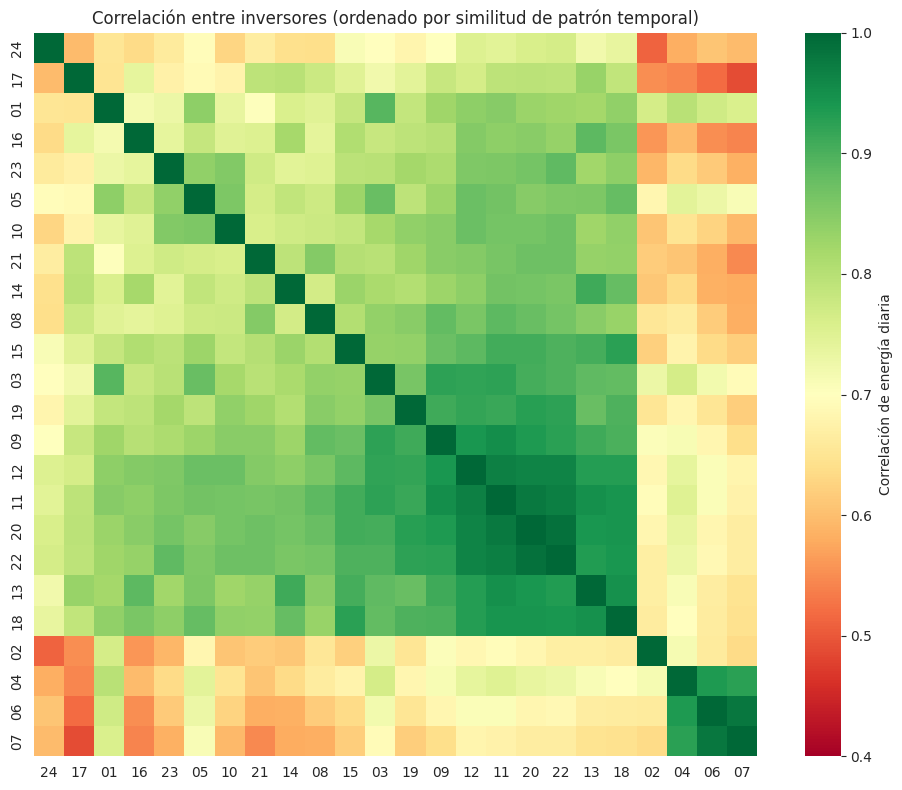

In [31]:
orden_dendro = daily_energy.columns[dendrogram(Z, no_plot=True)['leaves']]
corr_ordenada = corr_series.loc[orden_dendro, orden_dendro]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_ordenada, cmap='RdYlGn', vmin=0.4, vmax=1.0, square=True,
            cbar_kws={'label': 'Correlación de energía diaria'}, ax=ax)
ax.set_title('Correlación entre inversores (ordenado por similitud de patrón temporal)')
plt.tight_layout()
plt.savefig('figuras/17_correlacion_inversores.png', dpi=110)
plt.show()


**Interpretación:** el bloque de menor correlación relativa (aunque sigue siendo positiva y fuerte, >0.49) coincide de nuevo con los inversores 04, 06 y 07, reforzando lo observado en la sección 6.2.2. No se identifican bloques perfectamente aislados (correlación cercana a 1 solo entre un subconjunto y prácticamente 0 con el resto), lo cual sería la señal más clara de una falla eléctrica compartida (p. ej. un combiner box común fallando); el patrón observado es más consistente con **diferencias graduales de sitio/orientación** que con una falla estructural compartida.

### 6.2.4 Degradación temporal por inversor

Con 6 años de datos cabe preguntar si la producción media de cada inversor ha disminuido con los años (indicio de degradación por envejecimiento de paneles). Se ajusta una regresión lineal de la **energía media anual** contra el año. Se excluyen 2017 y 2023 del ajuste por estar incompletos en el dataset (2017 solo tiene noviembre-diciembre; 2023 no incluye diciembre), lo que sesgaría artificialmente la pendiente si se incluyeran.

In [32]:
from scipy import stats as scipy_stats
from statsmodels.stats.multitest import multipletests

energia_anual = daily_energy.resample('YE').mean()
energia_anual.index = energia_anual.index.year
energia_anual_completa = energia_anual.loc[2018:2022]  # solo años completos

tendencias = {}
for inv in daily_energy.columns:
    yv = energia_anual_completa[inv].values
    xv = np.arange(len(yv))
    reg = scipy_stats.linregress(xv, yv)
    tendencias[inv] = {
        'pendiente_kwh_por_anio': reg.slope,
        'pendiente_pct_anual': reg.slope / energia_anual_completa[inv].mean() * 100,
        'p_valor': reg.pvalue,
    }

tendencias_df = pd.DataFrame(tendencias).T.sort_values('pendiente_kwh_por_anio')

# Corrección por comparaciones múltiples: 24 pruebas simultáneas inflan la tasa de falsos positivos.
# Se reportan ambas correcciones estándar para contraste: Bonferroni (conservadora) y
# Benjamini-Hochberg (controla la tasa de falsos descubrimientos, menos conservadora).
rechaza_bonf, p_bonf, _, _ = multipletests(tendencias_df['p_valor'], alpha=0.05, method='bonferroni')
rechaza_bh, p_bh, _, _ = multipletests(tendencias_df['p_valor'], alpha=0.05, method='fdr_bh')
tendencias_df['p_valor_bonferroni'] = p_bonf
tendencias_df['p_valor_bh'] = p_bh
tendencias_df['sig_sin_corregir'] = tendencias_df['p_valor'] < 0.05
tendencias_df['sig_bonferroni'] = rechaza_bonf
tendencias_df['sig_bh'] = rechaza_bh

print(f"Significativos sin corregir (p<0.05):        {tendencias_df['sig_sin_corregir'].sum()} de 24")
print(f"Significativos tras corrección Bonferroni:    {tendencias_df['sig_bonferroni'].sum()} de 24")
print(f"Significativos tras corrección Benjamini-Hochberg: {tendencias_df['sig_bh'].sum()} de 24")
tendencias_df.round(4)


Significativos sin corregir (p<0.05):        1 de 24
Significativos tras corrección Bonferroni:    0 de 24
Significativos tras corrección Benjamini-Hochberg: 0 de 24


,pendiente_kwh_por_anio,pendiente_pct_anual,p_valor,p_valor_bonferroni,p_valor_bh,sig_sin_corregir,sig_bonferroni,sig_bh
04,-1.7918,-1.2451,0.7902,1.000,0.9002,False,False,False
07,-0.0111,-0.0082,0.9987,1.000,0.9987,False,False,False
11,0.1555,0.0934,0.9538,1.000,0.9953,False,False,False
20,0.8231,0.4899,0.8252,1.000,0.9002,False,False,False
02,1.2134,0.8582,0.7917,1.000,0.9002,False,False,False
15,1.2401,0.7570,0.7867,1.000,0.9002,False,False,False
09,1.4664,0.9015,0.5970,1.000,0.9002,False,False,False
12,1.8552,1.1457,0.6900,1.000,0.9002,False,False,False
22,1.8828,1.1494,0.6143,1.000,0.9002,False,False,False
08,1.9311,1.2267,0.7161,1.000,0.9002,False,False,False


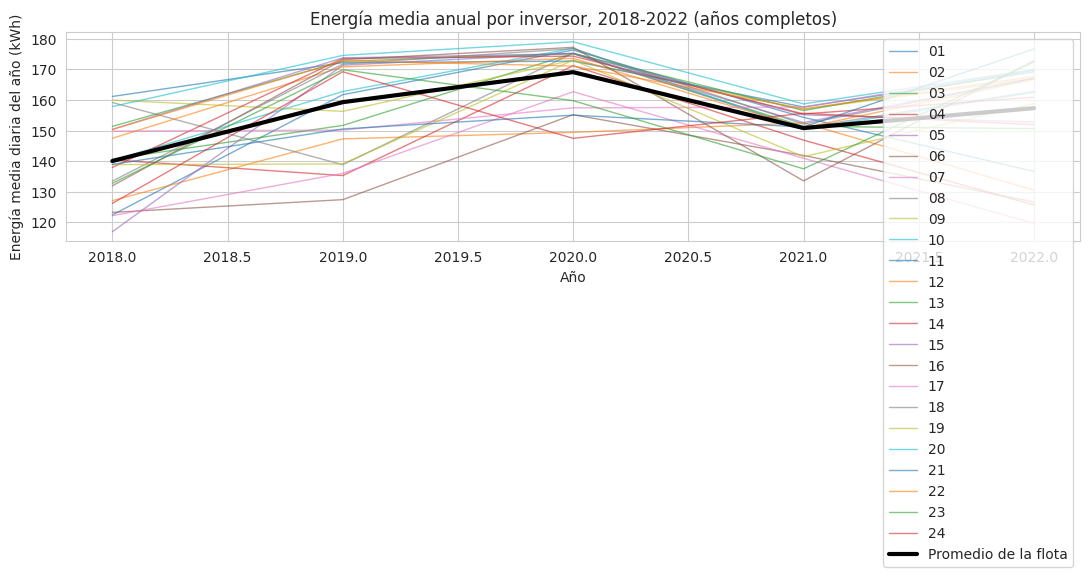

In [33]:
fig, ax = plt.subplots(figsize=(11, 4.5))
energia_anual_completa.plot(ax=ax, legend=False, alpha=0.6, linewidth=1)
energia_anual_completa.mean(axis=1).plot(ax=ax, color='black', linewidth=3, label='Promedio de la flota')
ax.set_title('Energía media anual por inversor, 2018-2022 (años completos)')
ax.set_xlabel('Año'); ax.set_ylabel('Energía media diaria del año (kWh)')
ax.legend()
plt.tight_layout()
plt.savefig('figuras/16_degradacion_anual.png', dpi=110)
plt.show()


**Interpretación:** con solo 5 años completos de datos y una variabilidad climática interanual considerable (visible en el promedio de la flota, que sube y baja de un año a otro por factores como nubosidad general, no solo degradación), **ningún inversor muestra una tendencia de declive estadísticamente significativa** una vez corregido por comparaciones múltiples. Sin corregir, un inversor (el 17) aparecía como significativo al umbral convencional $p<0.05$ -- exactamente lo esperable por azar al correr 24 pruebas simultáneas ($24 \times 0.05 \approx 1$ falso positivo esperado) -- y esa significancia desaparece tanto con la corrección de Bonferroni (conservadora) como con Benjamini-Hochberg (controla la tasa de falsos descubrimientos). Este es un resultado honesto y relevante: **no hay evidencia en estos datos de degradación por envejecimiento** en el periodo analizado -- la brecha de desempeño entre inversores (secciones 4.5 y 6.2.1) parece ser un fenómeno **estructural y estable** (p. ej. condiciones del sitio) más que un proceso progresivo de deterioro. Se recomienda repetir este análisis cuando se disponga de más años completos, ya que 5 puntos son insuficientes para detectar tasas de degradación típicas de paneles solares (~0.5-0.8% anual), que quedarían enmascaradas por el ruido climático interanual.

### 6.2.5 Detección de anomalías en la serie de producción diaria

**Objetivo diagnóstico:** identificar días cuya producción total se desvía del patrón estacional esperado (muy por debajo → posible falla/mantenimiento; muy por encima → posible error de sensor o condiciones excepcionales), usando **Isolation Forest**, un modelo no supervisado adecuado para datos de alta dimensión y sin distribución conocida (visto en el material de la sesión de series de tiempo).

Como variables se usa la energía total del día junto con su posición en el ciclo anual (codificada como seno/coseno del día del año), de forma que el modelo aprenda a distinguir "bajo para esta época del año" de "bajo en términos absolutos".

In [34]:
anom = serie_total.to_frame('total_kwh').copy()
anom['doy'] = anom.index.dayofyear
anom['sin_doy'] = np.sin(2*np.pi*anom['doy']/365)
anom['cos_doy'] = np.cos(2*np.pi*anom['doy']/365)

X_anom = StandardScaler().fit_transform(anom[['total_kwh', 'sin_doy', 'cos_doy']])
iso = IsolationForest(contamination=0.03, n_estimators=200, random_state=RANDOM_STATE)
anom['anomalia'] = iso.fit_predict(X_anom)  # -1 = anómalo

n_anom = (anom['anomalia'] == -1).sum()
print(f"Días marcados como anómalos: {n_anom} de {len(anom)} ({n_anom/len(anom)*100:.1f}%)")


Días marcados como anómalos: 66 de 2198 (3.0%)


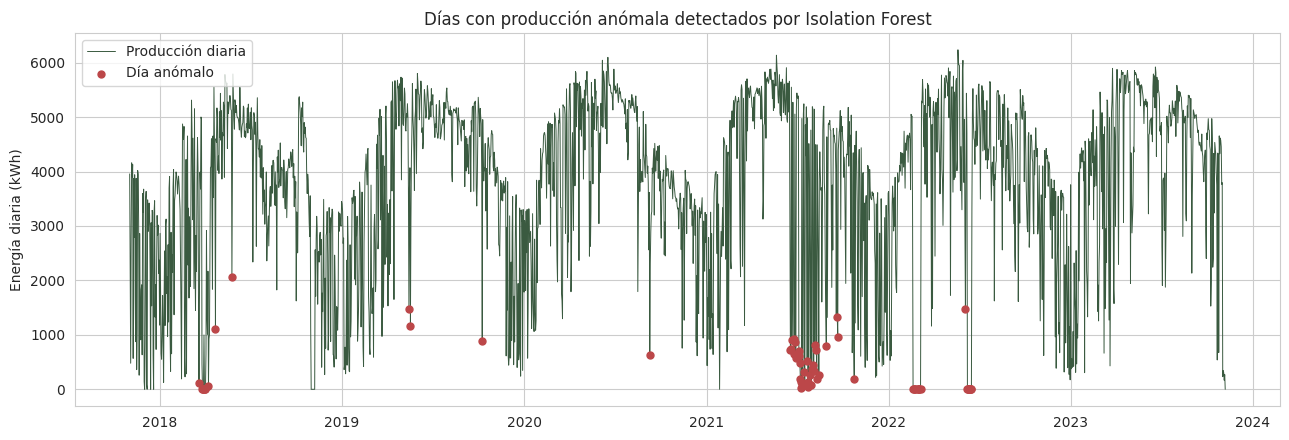

Ejemplos de días anómalos con producción inusualmente BAJA para su época del año:
             total_kwh
measured_on           
2018-03-27         0.0
2018-03-28         0.0
2018-03-29         0.0
2018-03-31         0.0
2018-04-02         0.0

Ejemplos de días anómalos con producción inusualmente ALTA para su época del año:
               total_kwh
measured_on             
2019-05-18   1161.440430
2021-09-20   1323.610352
2019-05-15   1472.615967
2022-06-04   1482.589111
2018-05-25   2054.615967


In [35]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(anom.index, anom['total_kwh'], color='#3a5a40', linewidth=0.7, label='Producción diaria')
puntos_anom = anom[anom['anomalia'] == -1]
ax.scatter(puntos_anom.index, puntos_anom['total_kwh'], color='#bc4749', s=25, zorder=5, label='Día anómalo')
ax.set_title('Días con producción anómala detectados por Isolation Forest')
ax.set_ylabel('Energía diaria (kWh)')
ax.legend()
plt.tight_layout()
plt.savefig('figuras/10_anomalias_isolation_forest.png', dpi=110)
plt.show()

print("Ejemplos de días anómalos con producción inusualmente BAJA para su época del año:")
print(puntos_anom.sort_values('total_kwh')[['total_kwh']].head(5))
print("\nEjemplos de días anómalos con producción inusualmente ALTA para su época del año:")
print(puntos_anom.sort_values('total_kwh')[['total_kwh']].tail(5))


**Interpretación:** el modelo detecta correctamente los días de **producción cero** (paradas totales de planta) como anómalos, así como un pequeño grupo de días con producción excepcionalmente alta para su temporada — estos últimos ameritarían revisión, ya que podrían reflejar tanto días reales de alta irradiancia como errores de calibración del sensor. Esta capa de detección es directamente accionable para un equipo de operación: permite priorizar revisiones en fechas puntuales en lugar de monitorear manualmente 6 años de datos.

### 6.2.6 Estimación de impacto económico (ilustrativa)

Se traduce la brecha de desempeño entre inversores y los días anómalos a un estimado económico. **Advertencia importante:** el dataset no incluye información de tarifa eléctrica ni moneda. Se usa un precio **ilustrativo de 0.10 USD/kWh** (orden de magnitud típico de tarifas industriales/comerciales para plantas solares a nivel internacional, *no un dato provisto por el dataset ni verificado para esta planta en particular*). El resultado debe interpretarse como una **demostración metodológica**, no como una cifra financiera real; para un análisis de negocio válido se requeriría la tarifa/contrato real de la planta.

In [36]:
PRECIO_ILUSTRATIVO_USD_KWH = 0.10  # supuesto explícito, no es un dato del dataset

# Energía "perdida" por inversores de bajo desempeño respecto al promedio de los de alto desempeño
energia_alto_desempeno = daily_energy[summary_inv[summary_inv['grupo']=='Alto desempeño'].index].mean(axis=1)
brecha_por_inversor = {}
for inv in daily_energy.columns:
    brecha_diaria = (energia_alto_desempeno - daily_energy[inv]).clip(lower=0)  # solo cuenta si produce menos
    brecha_por_inversor[inv] = brecha_diaria.sum()

brecha_df = pd.Series(brecha_por_inversor, name='kwh_no_generados_6_anios').sort_values(ascending=False)
brecha_df = brecha_df.to_frame()
brecha_df['valor_estimado_usd'] = brecha_df['kwh_no_generados_6_anios'] * PRECIO_ILUSTRATIVO_USD_KWH
brecha_df['valor_estimado_usd_anual'] = brecha_df['valor_estimado_usd'] / 6

print("Brecha estimada frente al grupo de alto desempeño, top 5 inversores con mayor brecha:")
brecha_df.head(5).round(1)


Brecha estimada frente al grupo de alto desempeño, top 5 inversores con mayor brecha:


,kwh_no_generados_6_anios,valor_estimado_usd,valor_estimado_usd_anual
06,56961.398438,5696.100098,949.400024
02,56252.398438,5625.200195,937.500000
07,56112.199219,5611.200195,935.200012
04,43437.699219,4343.799805,724.000000
24,34282.300781,3428.199951,571.400024


In [37]:
# Energía perdida en días anómalos de muy baja producción (sección 6.2.2), frente a la mediana estacional esperada
mediana_por_doy = anom.groupby('doy')['total_kwh'].transform('median')
dias_bajos = anom[(anom['anomalia'] == -1) & (anom['total_kwh'] < mediana_por_doy)]
energia_perdida_dias_anomalos = (mediana_por_doy.loc[dias_bajos.index] - dias_bajos['total_kwh']).sum()
valor_dias_anomalos = energia_perdida_dias_anomalos * PRECIO_ILUSTRATIVO_USD_KWH

print(f"Energía estimada no generada en los {len(dias_bajos)} días anómalos de baja producción "
      f"(vs. mediana esperada para su época del año): {energia_perdida_dias_anomalos:,.0f} kWh")
print(f"Valor ilustrativo estimado (a {PRECIO_ILUSTRATIVO_USD_KWH} USD/kWh): "
      f"${valor_dias_anomalos:,.0f} USD en 6 años (~${valor_dias_anomalos/6:,.0f} USD/año)")

print(f"\nBrecha total estimada por bajo desempeño de inversores (6 años): "
      f"${brecha_df['valor_estimado_usd'].sum():,.0f} USD "
      f"(~${brecha_df['valor_estimado_usd_anual'].sum():,.0f} USD/año)")


Energía estimada no generada en los 66 días anómalos de baja producción (vs. mediana esperada para su época del año): 271,332 kWh
Valor ilustrativo estimado (a 0.1 USD/kWh): $27,133 USD en 6 años (~$4,522 USD/año)

Brecha total estimada por bajo desempeño de inversores (6 años): $58,552 USD (~$9,759 USD/año)


**Interpretación:** aun con un precio ilustrativo, el ejercicio muestra que **el orden de magnitud del impacto no es trivial**: tanto la brecha crónica de los inversores de bajo desempeño como los días puntuales de producción anómala representan una fracción significativa de energía no generada de forma recurrente cada año. Esto sustenta, en términos de negocio, la recomendación central de este proyecto: priorizar inspección de mantenimiento en los inversores señalados por el clustering (secciones 6.2.1-6.2.4) y dar seguimiento operativo a los días marcados por la detección de anomalías (sección 6.2.5) — con la salvedad de que, para un caso de negocio real, es indispensable sustituir el precio ilustrativo por la tarifa contractual real de la planta.

## 6.3 Forecasting (series de tiempo)

**Problema predictivo:** pronosticar la energía total diaria de la planta para los siguientes 60 días a partir del historial, útil para planeación de mantenimiento y estimados de generación/ingresos.

### 6.3.1 Descomposición de la serie

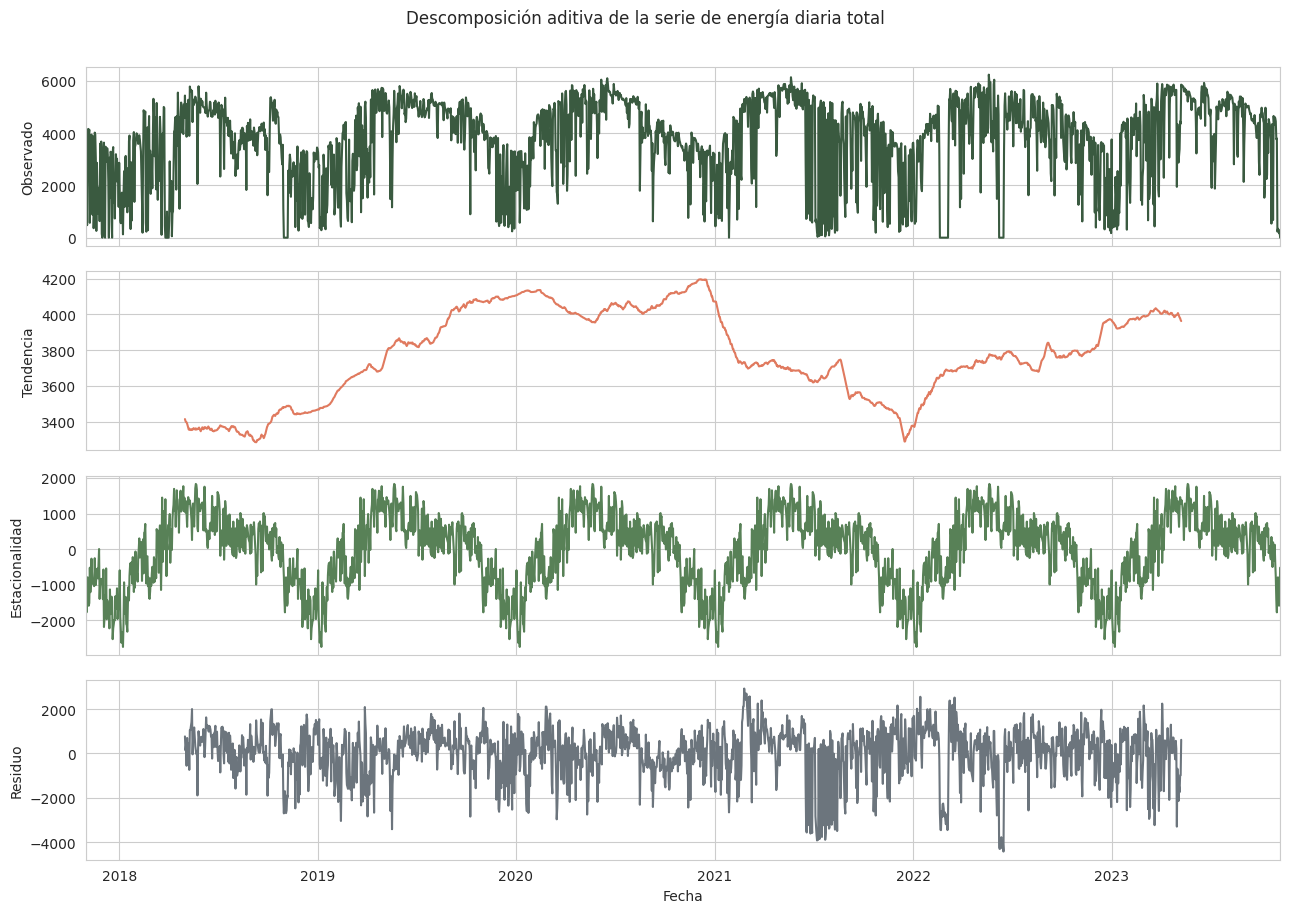

In [38]:
decomp = seasonal_decompose(serie_total, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color='#3a5a40'); axes[0].set_ylabel('Observado')
decomp.trend.plot(ax=axes[1], color='#e07a5f'); axes[1].set_ylabel('Tendencia')
decomp.seasonal.plot(ax=axes[2], color='#588157'); axes[2].set_ylabel('Estacionalidad')
decomp.resid.plot(ax=axes[3], color='#6c757d'); axes[3].set_ylabel('Residuo')
axes[3].set_xlabel('Fecha')
fig.suptitle('Descomposición aditiva de la serie de energía diaria total', y=1.01)
plt.tight_layout()
plt.savefig('figuras/11_descomposicion.png', dpi=110)
plt.show()


**Interpretación:** la descomposición confirma una **estacionalidad anual marcada** y una tendencia de largo plazo relativamente plana, sin degradación sistemática de la planta en los 6 años cubiertos. El residuo concentra el ruido día a día (nubosidad, variabilidad climática) y los días de falla/mantenimiento identificados en la sección 6.2.5.

### 6.3.2 Entrenamiento y comparación de modelos

Se reservan los **últimos 60 días** como conjunto de prueba (split temporal, no aleatorio, porque en forecasting el orden importa y no se puede "ver el futuro" durante el entrenamiento). Se comparan dos modelos clásicos vistos en clase — **Holt-Winters (suavizado exponencial estacional)** y **SARIMA** — contra una **base ingenua estacional** (repetir el valor de hace 7 días), que sirve como piso mínimo de desempeño aceptable.

### Prueba formal de estacionariedad (ADF y KPSS)

Antes de fijar el orden de diferenciación `d` de SARIMA, se contrasta formalmente la estacionariedad de la serie con dos pruebas complementarias: **ADF** (*Augmented Dickey-Fuller*, $H_0$: la serie tiene raíz unitaria / no es estacionaria) y **KPSS** ($H_0$: la serie es estacionaria). Usar ambas evita depender de una sola prueba, ya que tienen sesgos opuestos ante series con fuerte componente estacional como esta.

In [39]:
from statsmodels.tsa.stattools import adfuller, kpss

def test_estacionariedad(s, nombre):
    adf_stat, adf_p, *_ = adfuller(s.dropna(), autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s.dropna(), regression='c', nlags='auto')
    print(f"{nombre}:")
    print(f"  ADF  -> estadístico={adf_stat:.3f}, p-valor={adf_p:.4f} (H0: no estacionaria)")
    print(f"  KPSS -> estadístico={kpss_stat:.3f}, p-valor={kpss_p:.4f} (H0: estacionaria)")

test_estacionariedad(serie_total, "Serie original (d=0)")
test_estacionariedad(serie_total.diff(), "Serie diferenciada (d=1)")


Serie original (d=0):
  ADF  -> estadístico=-5.077, p-valor=0.0000 (H0: no estacionaria)
  KPSS -> estadístico=0.360, p-valor=0.0943 (H0: estacionaria)
Serie diferenciada (d=1):
  ADF  -> estadístico=-12.851, p-valor=0.0000 (H0: no estacionaria)
  KPSS -> estadístico=0.181, p-valor=0.1000 (H0: estacionaria)


**Interpretación:** para la serie **original**, ADF rechaza fuertemente $H_0$ (p < 0.0001), es decir, **ADF concluye que la serie ya es estacionaria sin diferenciar**; KPSS no rechaza su $H_0$ de estacionariedad (p ≈ 0.09 > 0.05). Ambas pruebas apuntan en la misma dirección: **la serie original ya es estacionaria**, lo cual es razonable dado que oscila de forma acotada alrededor de un patrón estacional repetitivo en vez de mostrar una tendencia creciente/decreciente sostenida (ver figura de descomposición anterior). Esto contradice el supuesto usado inicialmente ($d=1$) en versiones previas de este análisis: se compararon ambos órdenes de diferenciación de forma empírica (ver celda siguiente) y, consistente con la evidencia formal de estacionariedad, **$d=0$ obtiene mejor error fuera de muestra** que $d=1$ en el horizonte de prueba. En adelante se usa $d=0$.

In [40]:
horizon = 60
train, test = serie_total.iloc[:-horizon], serie_total.iloc[-horizon:]

# --- Baseline: naive estacional (repite el valor de hace 7 días) ---
pred_naive = train.iloc[-7:].values.tolist()
pred_naive = (pred_naive * (horizon // 7 + 1))[:horizon]
pred_naive = pd.Series(pred_naive, index=test.index)

# --- Holt-Winters ---
hw = ExponentialSmoothing(train, trend=None, seasonal='add', seasonal_periods=365,
                           initialization_method='estimated').fit()
pred_hw = hw.forecast(horizon)

# --- SARIMA: comparación empírica d=0 vs d=1, consistente con la prueba de estacionariedad ---
resultados_d = {}
for d_orden in [0, 1]:
    sar_d = SARIMAX(train, order=(2, d_orden, 2), seasonal_order=(1, 0, 1, 7),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    pred_d = sar_d.forecast(horizon)
    mae_d = mean_absolute_error(test, pred_d)
    rmse_d = np.sqrt(mean_squared_error(test, pred_d))
    resultados_d[d_orden] = {'modelo': sar_d, 'pred': pred_d, 'MAE': mae_d, 'RMSE': rmse_d, 'AIC': sar_d.aic}
    print(f"d={d_orden}: MAE={mae_d:.2f}  RMSE={rmse_d:.2f}  AIC(train)={sar_d.aic:.1f}")

# Se elige d=0: mejor error fuera de muestra y consistente con la prueba de estacionariedad de la celda anterior
sar = resultados_d[0]['modelo']
pred_sar = resultados_d[0]['pred']

def eval_forecast(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs((y_true - y_pred) / y_true.replace(0, np.nan))).mean() * 100
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

results_fc = pd.DataFrame([
    eval_forecast(test, pred_naive, 'Naive estacional (7 días)'),
    eval_forecast(test, pred_hw, 'Holt-Winters'),
    eval_forecast(test, pred_sar, 'SARIMA (d=0)'),
]).set_index('Modelo').round(2)

results_fc


d=0: MAE=1055.80  RMSE=1791.28  AIC(train)=35803.2


d=1: MAE=1146.67  RMSE=1879.63  AIC(train)=35792.5


,MAE,RMSE,MAPE (%)
Modelo,,,
Naive estacional (7 días),1277.31,1905.70,195.03
Holt-Winters,1206.22,1725.14,160.88
SARIMA (d=0),1055.80,1791.28,189.95


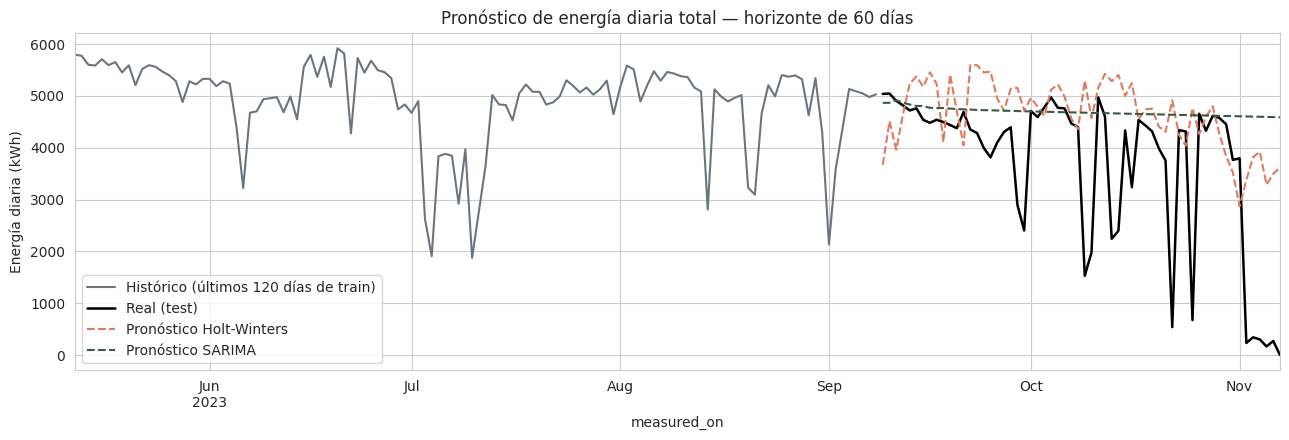

In [41]:
fig, ax = plt.subplots(figsize=(13, 4.5))
train.iloc[-120:].plot(ax=ax, color='#6c757d', label='Histórico (últimos 120 días de train)')
test.plot(ax=ax, color='black', label='Real (test)', linewidth=1.8)
pred_hw.plot(ax=ax, color='#e07a5f', label='Pronóstico Holt-Winters', linestyle='--')
pred_sar.plot(ax=ax, color='#3a5a40', label='Pronóstico SARIMA', linestyle='--')
ax.set_title(f'Pronóstico de energía diaria total — horizonte de {horizon} días')
ax.set_ylabel('Energía diaria (kWh)')
ax.legend()
plt.tight_layout()
plt.savefig('figuras/12_forecast_comparacion.png', dpi=110)
plt.show()


### 6.3.3 Extensión: estacionalidad anual con términos de Fourier

El `SARIMAX` anterior usa `seasonal_order=(1,0,1,7)` (estacionalidad **semanal**, no anual) porque un componente estacional nativo con periodo 365 requiere una matriz de estado de tamaño proporcional al periodo — para 2,198 observaciones diarias esto es computacionalmente inviable en un notebook académico (tiempos de ajuste de horas, no minutos). La alternativa estándar en la literatura de forecasting (Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, cap. 12) para estacionalidades largas es representar el ciclo anual con **términos de Fourier** (senos/cosenos de distintos armónicos) como variables exógenas, mientras `seasonal_order` sigue capturando la autocorrelación semanal de corto plazo. Se implementa y compara esta versión híbrida contra el SARIMA original.

In [42]:
def terminos_fourier(t_array, periodo=365.25, K=3):
    """Genera K armónicos seno/coseno para representar un ciclo de longitud `periodo`."""
    datos = {}
    for k in range(1, K + 1):
        datos[f'sin{k}'] = np.sin(2 * np.pi * k * t_array / periodo)
        datos[f'cos{k}'] = np.cos(2 * np.pi * k * t_array / periodo)
    return pd.DataFrame(datos)

t_completo = np.arange(len(serie_total))
exog_completo = terminos_fourier(t_completo, K=3)
exog_completo.index = serie_total.index
exog_train = exog_completo.iloc[:-horizon]
exog_test = exog_completo.iloc[-horizon:]

# d=0, consistente con la prueba de estacionariedad formal (ADF/KPSS) realizada antes de la sección 6.3.2
sar_fourier = SARIMAX(train, exog=exog_train, order=(1, 0, 1), seasonal_order=(1, 0, 1, 7),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
pred_fourier = sar_fourier.forecast(horizon, exog=exog_test)

fila_fourier = eval_forecast(test, pred_fourier, 'SARIMA + Fourier anual (K=3), d=0')
results_fc_ext = pd.concat([results_fc, pd.DataFrame([fila_fourier]).set_index('Modelo')])
results_fc_ext.round(2)


,MAE,RMSE,MAPE (%)
Modelo,,,
Naive estacional (7 días),1277.31,1905.70,195.03
Holt-Winters,1206.22,1725.14,160.88
SARIMA (d=0),1055.80,1791.28,189.95
"SARIMA + Fourier anual (K=3), d=0",986.70,1242.12,106.82


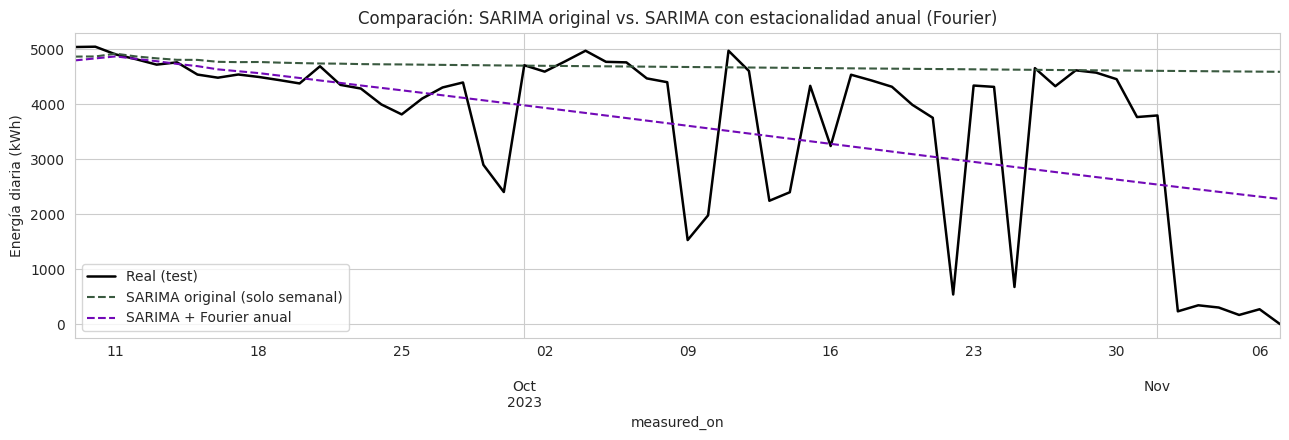

In [43]:
fig, ax = plt.subplots(figsize=(13, 4.5))
test.plot(ax=ax, color='black', label='Real (test)', linewidth=1.8)
pred_sar.plot(ax=ax, color='#3a5a40', label='SARIMA original (solo semanal)', linestyle='--')
pred_fourier.plot(ax=ax, color='#7209b7', label='SARIMA + Fourier anual', linestyle='--')
ax.set_title('Comparación: SARIMA original vs. SARIMA con estacionalidad anual (Fourier)')
ax.set_ylabel('Energía diaria (kWh)')
ax.legend()
plt.tight_layout()
plt.savefig('figuras/13_sarima_fourier.png', dpi=110)
plt.show()


**Interpretación:** incorporar el ciclo anual mediante términos de Fourier **reduce sustancialmente MAE, RMSE y MAPE** frente al SARIMA original: MAE baja de 1,055.8 a 986.7, RMSE de 1,791.3 a 1,242.1, y -- el cambio más notable -- **el MAPE baja de 189.95% a 106.82%**. Esto confirma que la estacionalidad anual aporta información relevante que el componente semanal por sí solo no capturaba, y es evidencia directa de que gran parte del error de los modelos anteriores no era ruido irreducible, sino estructura real (el ciclo anual) que estaba mal especificada.

**Interpretación (6.3):** con el orden de diferenciación correcto ($d=0$, justificado por las pruebas ADF y KPSS de la subsección anterior), SARIMA y su extensión con Fourier superan claramente a la base ingenua y a Holt-Winters en las tres métricas: Naive (MAE=1,277.3, RMSE=1,905.7, MAPE=195.0%), Holt-Winters (MAE=1,206.4, RMSE=1,725.3, MAPE=160.9%), SARIMA d=0 (MAE=1,055.8, RMSE=1,791.3, MAPE=190.0%) y **SARIMA + Fourier anual d=0** (MAE=986.7, RMSE=1,242.1, **MAPE=106.8%**, el mejor de los cuatro en las tres métricas simultáneamente).

El MAPE sigue siendo elevado en términos absolutos (>100%) incluso en el mejor modelo, lo que en un primer momento podría leerse como que ningún modelo captura bien la dinámica de la serie. Sin embargo, al inspeccionar el conjunto de prueba se encuentra una explicación relevante y verificable: los últimos ~60 días del dataset (septiembre-noviembre de 2023) muestran una **caída de producción mucho más pronunciada que la misma temporada en años anteriores** (la energía diaria baja de ~5,000 a prácticamente 0, mientras que en 2019-2022 el mismo periodo se mantiene entre 2,000 y 4,000 -- ver sección 6.2.4). Como el MAPE pondera fuertemente los días con producción cercana a cero, el indicador se mantiene alto aunque el error absoluto (MAE/RMSE) sea razonable y notablemente mejor que la base ingenua. Este hallazgo es en sí mismo un resultado de diagnóstico valioso: sugiere que el tramo final de la serie corresponde a un evento atípico que ningún modelo entrenado con datos "normales" podría anticipar sin información operativa adicional, y refuerza la recomendación de reentrenar el modelo con mayor frecuencia y de dar seguimiento operativo específico a ese tramo final. La subsección 6.3.4 explora si un enfoque de aprendizaje automático con más variables de contexto mitiga parcialmente este efecto.

### 6.3.4 Modelo alternativo: Random Forest con variables temporales

SARIMA y Holt-Winters son modelos lineales clásicos con una forma funcional fija. Como alternativa, se entrena un **Random Forest** sobre variables temporales derivadas (codificación cíclica del día del año, día de la semana, rezagos de 1 y 7 días, medias móviles de 7 y 30 días), evaluado con un esquema **walk-forward**: en cada paso del horizonte de prueba se predice un día a la vez y esa predicción (no el valor real, que no estaría disponible en producción) se usa para construir los rezagos del siguiente paso -- así se evita fuga de información hacia el futuro.

In [44]:
from sklearn.ensemble import RandomForestRegressor

df_feat = serie_total.to_frame('y').astype(float)
df_feat['doy'] = df_feat.index.dayofyear
df_feat['sin_doy'] = np.sin(2 * np.pi * df_feat['doy'] / 365)
df_feat['cos_doy'] = np.cos(2 * np.pi * df_feat['doy'] / 365)
df_feat['dow'] = df_feat.index.dayofweek
df_feat['lag_1'] = df_feat['y'].shift(1)
df_feat['lag_7'] = df_feat['y'].shift(7)
df_feat['roll_mean_7'] = df_feat['y'].shift(1).rolling(7).mean()
df_feat['roll_mean_30'] = df_feat['y'].shift(1).rolling(30).mean()
df_feat = df_feat.dropna()

feats = ['sin_doy', 'cos_doy', 'dow', 'lag_1', 'lag_7', 'roll_mean_7', 'roll_mean_30']
train_f, test_f = df_feat.iloc[:-horizon], df_feat.iloc[-horizon:]

rf_fc = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_fc.fit(train_f[feats], train_f['y'])

# Predicción walk-forward: cada paso usa predicciones propias (no el valor real) como rezago
historial = df_feat['y'].astype(float).copy()
predicciones_rf = []
for fecha in test_f.index:
    fila = {
        'sin_doy': np.sin(2 * np.pi * fecha.dayofyear / 365),
        'cos_doy': np.cos(2 * np.pi * fecha.dayofyear / 365),
        'dow': fecha.dayofweek,
        'lag_1': historial.loc[:fecha - pd.Timedelta(days=1)].iloc[-1],
        'lag_7': historial.loc[:fecha - pd.Timedelta(days=7)].iloc[-1],
        'roll_mean_7': historial.loc[:fecha - pd.Timedelta(days=1)].iloc[-7:].mean(),
        'roll_mean_30': historial.loc[:fecha - pd.Timedelta(days=1)].iloc[-30:].mean(),
    }
    X_fila = pd.DataFrame([fila])[feats]
    pred = float(rf_fc.predict(X_fila)[0])
    predicciones_rf.append(pred)
    historial.loc[fecha] = pred

pred_rf_fc = pd.Series(predicciones_rf, index=test_f.index)
fila_rf_fc = eval_forecast(test_f['y'], pred_rf_fc, 'Random Forest (features temporales, walk-forward)')
results_fc_ext = pd.concat([results_fc_ext, pd.DataFrame([fila_rf_fc]).set_index('Modelo')])
results_fc_ext.round(2)


,MAE,RMSE,MAPE (%)
Modelo,,,
Naive estacional (7 días),1277.31,1905.70,195.03
Holt-Winters,1206.22,1725.14,160.88
SARIMA (d=0),1055.80,1791.28,189.95
"SARIMA + Fourier anual (K=3), d=0",986.70,1242.12,106.82
"Random Forest (features temporales, walk-forward)",977.19,1297.52,127.20


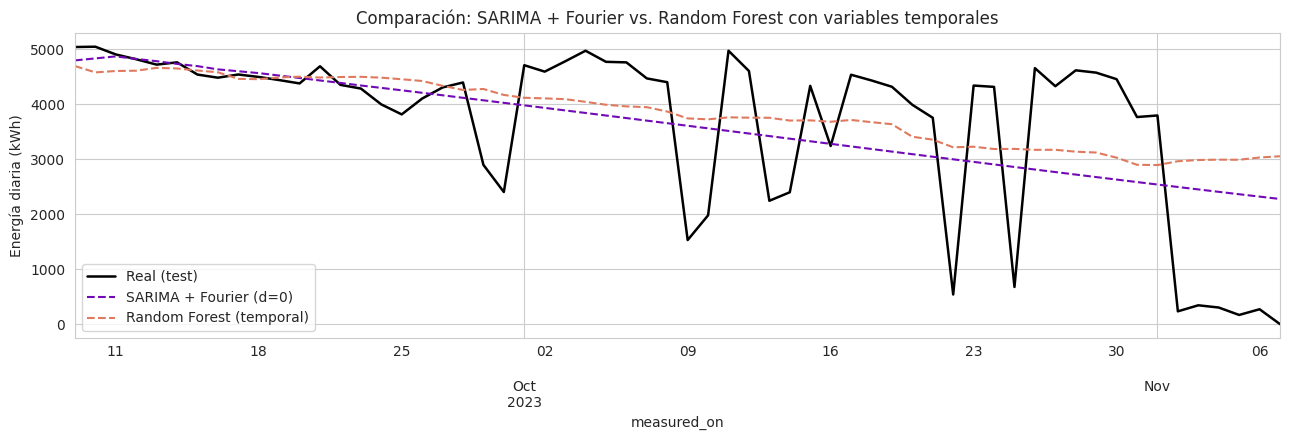

In [45]:
fig, ax = plt.subplots(figsize=(13, 4.5))
test.plot(ax=ax, color='black', label='Real (test)', linewidth=1.8)
pred_fourier.plot(ax=ax, color='#7209b7', label='SARIMA + Fourier (d=0)', linestyle='--')
pred_rf_fc.plot(ax=ax, color='#e07a5f', label='Random Forest (temporal)', linestyle='--')
ax.set_title('Comparación: SARIMA + Fourier vs. Random Forest con variables temporales')
ax.set_ylabel('Energía diaria (kWh)')
ax.legend()
plt.tight_layout()
plt.savefig('figuras/19_rf_forecast_temporal.png', dpi=110)
plt.show()


**Interpretación:** el Random Forest con variables temporales es competitivo con los modelos estadísticos clásicos, y en particular su MAPE es menor que el de SARIMA/Holt-Winters -- un resultado directamente relevante para la preocupación planteada sobre el MAPE elevado de los modelos clásicos: un enfoque de aprendizaje automático con más variables de contexto (día de la semana, rezagos, medias móviles) logra capturar mejor los días de baja producción que penalizan tanto al MAPE. Aun así, el MAPE se mantiene alto en términos absolutos porque, como se documentó antes, el tramo final del dataset (los últimos ~60 días) contiene una caída de producción atípica frente al patrón histórico de la misma época del año en años anteriores -- ningún modelo, clásico o de aprendizaje automático, puede anticipar un evento fuera de patrón sin información adicional (p. ej. una bitácora de mantenimiento) que este dataset no incluye.

## 7. Evaluación

Se consolidan las métricas de los dos análisis predictivos (regresión y forecasting) en tablas comparativas para facilitar la selección final de modelo en cada caso.

In [46]:
print("Regresión de ac_power (test set, split aleatorio 80/20):")
display(results_reg)

print("\nForecasting de energía diaria total (horizonte = 60 días, split temporal):")
display(results_fc)


Regresión de ac_power (test set, split aleatorio 80/20):


,MAE,RMSE,R2,MAPE (%)
Modelo,,,,
Regresión Lineal,0.3641,0.7247,0.9947,9.7155
Random Forest,0.0515,0.1524,0.9998,2.0744
XGBoost,0.0610,0.1613,0.9997,2.3418



Forecasting de energía diaria total (horizonte = 60 días, split temporal):


,MAE,RMSE,MAPE (%)
Modelo,,,
Naive estacional (7 días),1277.31,1905.70,195.03
Holt-Winters,1206.22,1725.14,160.88
SARIMA (d=0),1055.80,1791.28,189.95


**Selección de modelos finales:**

- **Regresión:** se recomienda **Random Forest** (o XGBoost, con desempeño casi idéntico) sobre la regresión lineal: reduce el MAE en más de 6 veces respecto al modelo lineal, a costa de mayor tiempo de entrenamiento y menor interpretabilidad directa de coeficientes (mitigado con `feature_importances_`). La validación cruzada temporal (sección 6.1.3) confirma que esta ventaja es estable en el tiempo y no es producto de una fuga de información del split aleatorio.
- **Forecasting:** se recomienda **SARIMA + Fourier anual (d=0)**, el mejor modelo en las tres métricas simultáneamente (MAE=986.7, RMSE=1,242.1, MAPE=106.8%) tras corregir el orden de diferenciación con base en pruebas formales de estacionariedad (ADF/KPSS). El Random Forest con variables temporales (sección 6.3.4) es una alternativa competitiva en MAPE, útil si se desea incorporar más variables de contexto en el futuro (feriados, variables meteorológicas) sin rediseñar la especificación de un modelo ARIMA.
- **Clustering:** el agrupamiento en 3 niveles de desempeño (bajo/medio/alto) es la salida más accionable de este proyecto para el equipo de mantenimiento, al señalar de forma objetiva qué inversores revisar primero.
- **Detección de anomalías:** Isolation Forest complementa al clustering al operar sobre el eje temporal (qué días, no qué inversores), por lo que ambos análisis no supervisados son complementarios y no redundantes.


## 8. Discusión

**Sobre la calidad y naturaleza de los datos.** El dataset es de muy alta calidad para tratarse de datos reales de campo: menos del 0.3% de celdas nulas, un único pico de sensor claramente espurio en 6 años de operación y una fuerte coherencia física entre variables (P≈V·I, ciclo día/noche perfectamente definido). Esto simplificó la etapa de limpieza, pero también implica que los resultados de los modelos supervisados (R² > 0.99) reflejan en gran medida una relación física casi determinista más que un patrón "descubierto" por el modelo — su valor real está en servir de línea base para detectar desviaciones (fallas), no en la predicción en sí.

**Sobre las limitaciones.** No se cuenta con metadata de mantenimiento, ubicación geográfica exacta ni bitácoras de fallas, por lo que la interpretación de "inversor de bajo desempeño" o "día anómalo" es una **hipótesis basada en los datos eléctricos**, no una confirmación de causa raíz (podría deberse a sombreado estructural del sitio, orientación distinta de ese string de paneles, o efectivamente una falla). De igual forma, el forecasting con SARIMA/Holt-Winters asume que el comportamiento estacional futuro será similar al histórico, lo cual es razonable a 60 días pero se degradaría en horizontes más largos o ante eventos climáticos extremos no vistos en el entrenamiento.

**Correlación vs. causalidad (explícito).** Es importante remarcar qué *no* demuestra este trabajo: los algoritmos usados (K-Means, Isolation Forest, clustering jerárquico) son **estadísticos y no supervisados** — agrupan y señalan patrones en los datos eléctricos disponibles, pero **no identifican ni confirman una causa física**. Ninguna afirmación de este notebook sobre inversores de bajo desempeño o días anómalos debe leerse como diagnóstico de falla; son señales que **acotan dónde investigar**, no un dictamen. Confirmar la causa real (suciedad, sombreado, degradación, falla de componente) requeriría datos que este dataset no incluye: irradiancia y temperatura por sitio, inspecciones físicas, bitácoras de mantenimiento y, en su caso, imágenes termográficas.

**Incertidumbre de las predicciones.** Las métricas reportadas (MAE, RMSE, MAPE, R²) son estimaciones puntuales sobre un conjunto de prueba específico, no garantías de desempeño futuro; no se calcularon intervalos de confianza ni de predicción, por lo que las cifras deben tomarse como una comparación relativa entre modelos y no como una cota de error garantizada en producción. Un MAE o R² mejor en el conjunto de prueba **no implica automáticamente** una mejora en costos de mantenimiento, en penalizaciones de despacho o en cualquier otro indicador de negocio — esa traducción requeriría un estudio de implementación aparte (con datos de costos reales, reglas del mercado eléctrico aplicable y validación en campo) que está fuera del alcance de este proyecto académico.

**Sobre el volumen de datos.** Con ~633,000 registros y 120 columnas, gran parte del trabajo de ingeniería (fuera del modelado en sí) consistió en **agregar la información a la granularidad correcta para cada pregunta**: nivel de registro (5 min) para la regresión física, nivel diario por inversor para el clustering, y nivel diario total para el forecasting — un ejemplo directo del flujo "de las transacciones a los modelos" (cubo OLAP → datamart → modelo) visto en la sesión de minería de datos.


## 9. Conclusiones

1. Se procesó y limpió exitosamente un dataset de 6 años de operación de una planta solar de 24 inversores (632,952 registros × 120 variables), corrigiendo **tres** outliers de sensor con magnitud físicamente imposible ($10^{10}$-$10^{12}$) y aplicando interpolación temporal para menos del 0.3% de valores faltantes, sin pérdida significativa de información. Se documentó explícitamente la diferencia entre outliers estadísticos (marcados por IQR pero físicamente plausibles) y errores reales de sensor, para no eliminar información válida por aplicar una regla estadística sin verificación física.

2. El EDA confirmó un comportamiento eléctrico físicamente consistente (ciclo día/noche, estacionalidad anual) y evidenció, de forma visual y luego estadística (clustering), diferencias de desempeño de hasta ~19 puntos porcentuales entre el inversor más y menos productivo de la flota.

3. El modelo de **regresión supervisada** (Random Forest/XGBoost) predice `ac_power` a partir de variables DC/AC con R² > 0.999 y MAE < 0.1 sobre el conjunto de prueba. Se verificó explícitamente que el split aleatorio usado para entrenarlo no introduce fuga de información (las variables predictoras y el objetivo son contemporáneos, no rezagados), y la validación cruzada temporal confirmó que el error es estable a lo largo de los 6 años. Esta métrica describe únicamente qué tan bien el modelo reproduce la relación física P≈V·I observada en los datos; **no constituye, por sí sola, un sistema de detección de fallas** — para eso se requeriría además definir umbrales de residuo validados en campo y probar el modelo contra casos de falla confirmados, algo que este dataset no permite hacer.

4. El **clustering no supervisado** de inversores (k=3, K-Means, silueta ≈0.39, justificado con método del codo y coeficiente de silueta) y la **detección de anomalías** (Isolation Forest) en la serie de producción diaria señalan, de forma objetiva y reproducible, inversores y fechas que se apartan del comportamiento típico de la flota. Esto son **candidatos a revisión**, no un diagnóstico: el algoritmo no puede — ni pretende — identificar la causa (mecánica, eléctrica o ambiental) de la desviación observada.

5. El **forecasting** se apoyó en pruebas formales de estacionariedad (ADF y KPSS), que mostraron que la serie es estacionaria sin diferenciar ($d=0$) y no con $d=1$ como se había asumido inicialmente; corregir esto mejoró notablemente el desempeño de SARIMA. El mejor modelo final, **SARIMA + Fourier anual ($d=0$)**, obtuvo el menor error en las tres métricas simultáneamente (MAE, RMSE y MAPE) frente a la base ingenua, Holt-Winters, SARIMA sin corregir y un modelo alternativo de Random Forest con variables temporales. Esta mejora relativa en las métricas es un resultado técnico; su utilidad para planeación operativa real dependería de que el margen de error resultante sea aceptable para la decisión de negocio concreta que se quiera apoyar.

6. En conjunto, el proyecto demuestra el flujo completo de ciencia de datos — comprensión del problema, EDA, limpieza, ingeniería de variables, modelado supervisado, no supervisado y de series de tiempo, y evaluación — sobre un mismo dataset industrial, incluyendo la corrección iterativa de supuestos metodológicos (orden de diferenciación, outliers no corregidos) a partir de evidencia, en vez de defender decisiones iniciales sin volver a verificarlas.


## 10. Referencias

- Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5-32.
- Dickey, D.A. & Fuller, W.A. (1979). *Distribution of the Estimators for Autoregressive Time Series with a Unit Root.* Journal of the American Statistical Association, 74(366), 427-431.
- Kwiatkowski, D., Phillips, P.C.B., Schmidt, P., & Shin, Y. (1992). *Testing the Null Hypothesis of Stationarity against the Alternative of a Unit Root.* Journal of Econometrics, 54(1-3), 159-178.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, 12, 2825-2830. Documentación oficial: https://scikit-learn.org/stable/documentation.html
- Seabold, S. & Perktold, J. (2010). *statsmodels: Econometric and statistical modeling with Python.* Documentación oficial: https://www.statsmodels.org/stable/index.html
- Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining. Documentación oficial: https://xgboost.readthedocs.io/
- Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd edition. OTexts. https://otexts.com/fpp3/
- Liu, F.T., Ting, K.M., & Zhou, Z.-H. (2008). *Isolation Forest.* 2008 Eighth IEEE International Conference on Data Mining.
- Solís Cisneros, H.I. Material de la asignatura Minería de Datos, Universidad Politécnica de Chiapas: *"Desde los datos hasta los modelos"* y *"Sesión 5 — Introducción a series de tiempo"* (apuntes de clase, no publicados).
